In [1]:
import os
from datasets import load_dataset, Dataset
from tqdm.auto import tqdm
import json
from dotenv import load_dotenv
import re
import pandas as pd

import google.auth
import vertexai
from google.cloud import bigquery, storage
import google.generativeai as genai

from vertexai.generative_models import (
    GenerativeModel,
    GenerationConfig,
    HarmCategory,
    HarmBlockThreshold,
    GenerationResponse,
)
import asyncio
from asynciolimiter import Limiter
from tqdm.asyncio import tqdm_asyncio

import jsonlines
import nest_asyncio

from typing import List, Dict, Tuple
from langchain_community.utilities.python import PythonREPL

import threading
from functools import wraps
from sympy.parsing import parse_expr
from sympy.parsing.latex import parse_latex

from transformers import AutoTokenizer
from huggingface_hub import HfFileSystem, hf_hub_download

tqdm.pandas()
nest_asyncio.apply()
load_dotenv('../.env')

True

In [2]:
# CONFIG Bucket
CONFIG_BUCKET = "tmhcc-dev-intermediate"

credentials, project_id = google.auth.default()
LOCATION = os.getenv("GCP_LOCATION")

vertexai.init(
    project=os.getenv("GCP_PROJECT"), location=LOCATION, credentials=credentials
)

storage_client = storage.Client()
bigquery_client = bigquery.Client()
genai.configure(api_key=os.getenv("GOOGLE_AI_STUDIO_API_KEY"))

In [3]:
ROOT_DATA_DIR = os.path.join("..", "..", "..", *os.getenv("DATA_DIR").split(","))
METAMATH_DIR = os.path.join(ROOT_DATA_DIR, "Math-Problems", "MetaMathQA")
MATH_DIR = os.path.join(ROOT_DATA_DIR, "Math-Problems", "MATH")
MMOS_DIR = os.path.join(ROOT_DATA_DIR, "Math-Problems", "MMOS")
INTERIM_FOLDER = os.path.join(ROOT_DATA_DIR, "InterimFiles")

os.path.exists(ROOT_DATA_DIR), os.path.exists(METAMATH_DIR), os.path.exists(MATH_DIR), os.path.exists(MMOS_DIR), os.path.exists(INTERIM_FOLDER)

(True, False, False, False, True)

In [4]:
metamath_ds = load_dataset('meta-math/MetaMathQA')['train']
metamath_df = metamath_ds.to_pandas()

MATH_ds = load_dataset('hendrycks/competition_math', trust_remote_code=True)['train']
MATH_df = MATH_ds.to_pandas()

# mathllms_ds = load_dataset('MathLLMs/MathCodeInstruct-Plus')['train']
# mathllms_df = mathllms_ds.to_pandas()

# mmos_ds = load_dataset('cyzhh/MMOS')['train']
# mmos_df = mmos_ds.to_pandas()

# ## Start Here: microsoft/orca-math-word-problems-200k
# msft_orca_math_ds = load_dataset('microsoft/orca-math-word-problems-200k')['train']
# msft_orca_math_df = msft_orca_math_ds.to_pandas()

## Meta-Math

In [5]:
steps, fa = metamath_df['response'][0].split('The answer is: ')
steps = steps.strip()
fa

'\\sqrt{5}'

In [6]:
print(r'\b')

\b


In [7]:
steps.split('.\n')  

['The distance between two points $(x_1,y_1)$ and $(x_2,y_2)$ in the complex plane is given by the formula $\\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}$',
 "In this case, Joe's point is $(1,2)$ and Gracie's point is $(-1,1)$",
 'So the distance between their points is $\\sqrt{((-1)-(1))^2+((1)-(2))^2}=\\sqrt{(-2)^2+(-1)^2}=\\sqrt{4+1}=\\sqrt{5}$',
 "Therefore, Gracie and Joe's points are $\\boxed{\\sqrt{5}}$ units apart."]

In [8]:
metamath_df['final_answer'] = metamath_df['response'].progress_apply(lambda x: x.split('The answer is: ')[1].strip())
metamath_df['final_answer_is_numeric'] = metamath_df['final_answer'].progress_apply(lambda x: x.isnumeric())

  0%|          | 0/395000 [00:00<?, ?it/s]

  0%|          | 0/395000 [00:00<?, ?it/s]

In [9]:
final_df_1 = metamath_df.drop_duplicates(subset=['query'], keep='first').copy(deep=True).reset_index(drop=True) # 146122

In [26]:
metamath_numeric_df = metamath_df[metamath_df['final_answer_is_numeric']].copy(deep=True).reset_index(drop=True)
metamath_numeric_df

,type,query,original_question,response,final_answer,final_answer_is_numeric
0,GSM_Rephrased,What is the total cost of purchasing equipment...,The treasurer of a football team must buy equi...,"Each player requires a $25 jersey, a $15.20 pa...",752,True
1,GSM_SV,Diego baked 12 cakes for his sister's birthday...,Diego baked 12 cakes for his sister's birthday...,"To solve this problem, we need to determine th...",1,True
2,MATH_AnsAug,Convert $10101_3$ to a base 10 integer.,Convert $10101_3$ to a base 10 integer.,$10101_3 = 1 \cdot 3^4 + 0 \cdot 3^3 + 1 \cdot...,91,True
3,GSM_FOBAR,"Sue works in a factory and every 30 minutes, a...","Sue works in a factory and every 30 minutes, a...","We know that every 30 minutes, a machine produ...",1,True
4,GSM_FOBAR,Mark is buying asphalt to pave a new section o...,Mark is buying asphalt to pave a new section o...,The area of the road is the length multiplied ...,75,True
...,...,...,...,...,...,...
356068,GSM_FOBAR,"Yesterday, David and William were invited to a...","Yesterday, David and William were invited to a...",David broke 2 glasses.\nHis friend William bro...,4,True
356069,MATH_AnsAug,Suppose $\sin N = \frac{2}{3}$ in the diagram ...,Suppose $\sin N = \frac{2}{3}$ in the diagram ...,We can use the Pythagorean Theorem to find $LN...,24,True
356070,GSM_FOBAR,Jeff orders a Halloween costume. He has to pu...,Jeff orders a Halloween costume. He has to pu...,The costume cost 40% more than last year's cos...,250,True
356071,MATH_AnsAug,The average age of the 10 females in a choir i...,The average age of the 10 females in a choir i...,The sum of the ages of the 10 females is $10 \...,33,True


In [27]:
metamath_numeric_dedup_df = metamath_numeric_df.drop_duplicates(subset=['query'], keep='first').copy(deep=True).reset_index(drop=True)
metamath_numeric_dedup_df

,type,query,original_question,response,final_answer,final_answer_is_numeric
0,GSM_Rephrased,What is the total cost of purchasing equipment...,The treasurer of a football team must buy equi...,"Each player requires a $25 jersey, a $15.20 pa...",752,True
1,GSM_SV,Diego baked 12 cakes for his sister's birthday...,Diego baked 12 cakes for his sister's birthday...,"To solve this problem, we need to determine th...",1,True
2,MATH_AnsAug,Convert $10101_3$ to a base 10 integer.,Convert $10101_3$ to a base 10 integer.,$10101_3 = 1 \cdot 3^4 + 0 \cdot 3^3 + 1 \cdot...,91,True
3,GSM_FOBAR,"Sue works in a factory and every 30 minutes, a...","Sue works in a factory and every 30 minutes, a...","We know that every 30 minutes, a machine produ...",1,True
4,GSM_FOBAR,Mark is buying asphalt to pave a new section o...,Mark is buying asphalt to pave a new section o...,The area of the road is the length multiplied ...,75,True
...,...,...,...,...,...,...
136938,GSM_Rephrased,If John starts at an elevation of 400 feet and...,John starts at an elevation of 400 feet. He t...,If John descends at a rate of 10 feet per minu...,350,True
136939,GSM_SV,The total cost of Olivia’s groceries was x. Th...,The total cost of Olivia’s groceries was $42. ...,"To solve this problem, we need to determine th...",42,True
136940,GSM_Rephrased,If each of the ten fourth-graders bought 20 pi...,Doc's Pizza contains 6 pieces of pizza. Ten fo...,"If each fourth-grader bought 20 pizzas, then t...",1200,True
136941,GSM_Rephrased,"Janet, a third-grade teacher, is collecting th...","Janet, a third grade teacher, is picking up th...",The total number of lunches needed is 35 child...,308,True


In [81]:
# Replace latex \( \) with $ $ and \[ \] with $$ $$
def replace_latex(x):
    x = re.sub(r'\\(', '$', x)
    x = re.sub(r'\\)', '$', x)
    x = re.sub(r'\\[', '$$', x)
    x = re.sub(r'\\]', '$$', x)
    return x

In [82]:
# Remove more than 1 `\` backslashes with single
def remove_backslashes(x):
    x = re.sub(r'\+(\w)', r'\\1', x)
    x = re.sub(r'\+\n', '\n', x)
    return x

In [86]:
metamath_numeric_dedup_df['query'] = metamath_numeric_dedup_df['query'].progress_apply(remove_backslashes).progress_apply(replace_latex)
metamath_numeric_dedup_df['original_question'] = metamath_numeric_dedup_df['original_question'].progress_apply(remove_backslashes).progress_apply(replace_latex)
metamath_numeric_dedup_df['response'] = metamath_numeric_dedup_df['response'].progress_apply(remove_backslashes).progress_apply(replace_latex)

  0%|          | 0/136943 [00:00<?, ?it/s]

  0%|          | 0/136943 [00:00<?, ?it/s]

  0%|          | 0/136943 [00:00<?, ?it/s]

  0%|          | 0/136943 [00:00<?, ?it/s]

  0%|          | 0/136943 [00:00<?, ?it/s]

  0%|          | 0/136943 [00:00<?, ?it/s]

In [87]:
metamath_numeric_dedup_df['steps'] = metamath_numeric_dedup_df['response'].progress_apply(lambda x: x.split('The answer is: ')[0].strip().split('.\n'))
metamath_numeric_dedup_df

  0%|          | 0/136943 [00:00<?, ?it/s]

,type,query,original_question,response,final_answer,final_answer_is_numeric,steps
0,GSM_Rephrased,What is the total cost of purchasing equipment...,The treasurer of a football team must buy equi...,"Each player requires a $25 jersey, a $15.20 pa...",752,True,"[Each player requires a $25 jersey, a $15.20 p..."
1,GSM_SV,Diego baked 12 cakes for his sister's birthday...,Diego baked 12 cakes for his sister's birthday...,"To solve this problem, we need to determine th...",1,True,"[To solve this problem, we need to determine t..."
2,MATH_AnsAug,Convert $10101_3$ to a base 10 integer.,Convert $10101_3$ to a base 10 integer.,$10101_3 = 1 \cdot 3^4 + 0 \cdot 3^3 + 1 \cdot...,91,True,[$10101_3 = 1 \cdot 3^4 + 0 \cdot 3^3 + 1 \cdo...
3,GSM_FOBAR,"Sue works in a factory and every 30 minutes, a...","Sue works in a factory and every 30 minutes, a...","We know that every 30 minutes, a machine produ...",1,True,"[We know that every 30 minutes, a machine prod..."
4,GSM_FOBAR,Mark is buying asphalt to pave a new section o...,Mark is buying asphalt to pave a new section o...,The area of the road is the length multiplied ...,75,True,[The area of the road is the length multiplied...
...,...,...,...,...,...,...,...
136938,GSM_Rephrased,If John starts at an elevation of 400 feet and...,John starts at an elevation of 400 feet. He t...,If John descends at a rate of 10 feet per minu...,350,True,[If John descends at a rate of 10 feet per min...
136939,GSM_SV,The total cost of Olivia’s groceries was x. Th...,The total cost of Olivia’s groceries was $42. ...,"To solve this problem, we need to determine th...",42,True,"[To solve this problem, we need to determine t..."
136940,GSM_Rephrased,If each of the ten fourth-graders bought 20 pi...,Doc's Pizza contains 6 pieces of pizza. Ten fo...,"If each fourth-grader bought 20 pizzas, then t...",1200,True,"[If each fourth-grader bought 20 pizzas, then ..."
136941,GSM_Rephrased,"Janet, a third-grade teacher, is collecting th...","Janet, a third grade teacher, is picking up th...",The total number of lunches needed is 35 child...,308,True,[The total number of lunches needed is 35 chil...


In [95]:
idx = 1
print(metamath_numeric_dedup_df[metamath_numeric_dedup_df['response'].str.contains('matrix')].response.values[idx], end='\n\n')
steps = metamath_numeric_dedup_df[metamath_numeric_dedup_df['response'].str.contains('matrix')].steps.values[idx]
print(f"Total Steps: {len(steps)}")
for step in steps:
    print(step, end='\n\n')

The matrix transformation is given by $\begin{pmatrix} 2 & 1 \\ 7 & -3 \end{pmatrix}$
To find the area of the transformed region, we need to find the determinant of the matrix, which is $2(-3) - 1(7) = -6 - 7 = -13$
Since the determinant is negative, the transformation will result in a reflection and a change in orientation of the region S
The absolute value of the determinant gives the factor by which the area is scaled, so the area of S' is $|-13| \cdot 10 = 13 \cdot 10 = \boxed{130}$
The answer is: 130

Total Steps: 1
The matrix transformation is given by $\begin{pmatrix} 2 & 1 \\ 7 & -3 \end{pmatrix}$
To find the area of the transformed region, we need to find the determinant of the matrix, which is $2(-3) - 1(7) = -6 - 7 = -13$
Since the determinant is negative, the transformation will result in a reflection and a change in orientation of the region S
The absolute value of the determinant gives the factor by which the area is scaled, so the area of S' is $|-13| \cdot 10 = 13 \cdot

In [41]:
total_examples = metamath_numeric_dedup_df.shape[0]
for idx, row in tqdm(metamath_numeric_dedup_df.iterrows(), total=total_examples):
    
    data = {
        "Exp_ID": f"Exp{idx:0>6}",
        "Original_Problem": row['original_question'],
        "Problem": row['query'],
        "Original_Solution": row['response'],
        "Final_Answer": row['final_answer'],
    }

    with open(os.path.join(METAMATH_DIR, f"Exp{idx:0>6}.json"), "w") as f:
        json.dump(data, f, indent=4)

  0%|          | 0/136943 [00:00<?, ?it/s]

## MATH

In [10]:
MATH_df

,problem,level,type,solution
0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"For the piecewise function to be continuous, t..."
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...
2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,This polynomial is not written in standard for...
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12..."
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...
...,...,...,...,...
7495,Find the number of real solutions of the equat...,Level 3,Precalculus,"Since $-1 \le \sin x \le 1,$ all solutions mus..."
7496,"Let $A,$ $B,$ $C$ be the angles of a triangle....",Level 2,Precalculus,We can expand the determinant as follows:\n\be...
7497,"Let $G$ be the centroid of triangle $ABC,$ and...",Level 2,Precalculus,"Let $\mathbf{a}$ denote $\overrightarrow{A},$ ..."
7498,If angle $A$ lies in the second quadrant and $...,Level 2,Precalculus,"Since angle $A$ lies in the second quadrant, $..."


In [11]:
MATH_df.solution[889]

'$\\textbf{Solution 1}$: Let the three numbers be $a$, $b$, and $c$, and WLOG assume that $a\\le b \\le c$. We have the three equations \\begin{align*}\na+b+c&=67\\\\\nc-b&=7\\\\\nb-a&=3\n\\end{align*} From the second equation, we have $c=b+7$. Substituting this into the first equation to eliminate $c$, we have $a+b+(b+7)=67\\Rightarrow a+2b=60$. Adding this last equation to the third equation, we have $a+2b+b-a=60+3\\Rightarrow b=21$. Substituting this value into the second equation to find $c$, we get $c=b+7=28$. Thus, the largest number is $\\boxed{28}$.\n\n$\\textbf{Solution 2}$: Let the middle number be $x.$ Then, the largest number is $x+7$ and the smallest number is $x-3.$ The numbers have a sum of $67,$ so we have the equation $$(x-3) + (x) + (x+7) = 67.$$ Simplifying, we get $$3x + 4 = 67$$ $$\\implies x = 21.$$ So, the largest number is $x+7 = 21+7 = \\boxed{28}.$'

In [12]:
sols = re.findall(r'\boxed\{(.*?)\}', MATH_df.solution[889], re.DOTALL)

# Check if all are same
all(sol == sols[0] for sol in sols)

True

In [27]:
re.findall(r"\\boxed\{(.*?)\}", MATH_df.solution[0], re.DOTALL)

['0']

In [29]:
def get_final_solution(x):
    sols = re.findall(r'\boxed\{(.*?)\}', x, re.DOTALL)

    if len(sols) == 0:
        sols = re.findall(r'\boxed (.*?)\$', x, re.DOTALL)
    
    if len(sols) == 0:
        sols = re.findall(r"\\boxed\{(.*?)\}", x, re.DOTALL)
    
    if len(sols) == 0:
        sols = re.findall(r"\\boxed\s+(.*?)", x, re.DOTALL)
    
    # Check if all are same
    try:
        if all(sol == sols[0] for sol in sols):
            return sols[0]
        else:
            return sols[-1]
    except:
        print(sols)
        print(x)
        raise

MATH_df['final_answer'] = MATH_df['solution'].progress_apply(lambda x: get_final_solution(x))
MATH_df['final_answer_is_numeric'] = MATH_df['final_answer'].progress_apply(lambda x: x.isnumeric())

MATH_numeric_df = MATH_df[MATH_df['final_answer_is_numeric']].copy(deep=True).reset_index(drop=True)
MATH_numeric_df


  0%|          | 0/7500 [00:00<?, ?it/s]

  0%|          | 0/7500 [00:00<?, ?it/s]

,problem,level,type,solution,final_answer,final_answer_is_numeric
0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"For the piecewise function to be continuous, t...",0,True
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...,98,True
2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,This polynomial is not written in standard for...,4,True
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12...",17,True
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...,6,True
...,...,...,...,...,...,...
4416,Find the smallest positive integer $k$ such th...,Level 5,Precalculus,"First, we factor the given polynomial. The po...",84,True
4417,"Define the sequence $a_1, a_2, a_3, \ldots$ by...",Level 5,Precalculus,"By the product-to-sum formula,\n\[\sin \frac{1...",628,True
4418,Find the number of real solutions of the equat...,Level 3,Precalculus,"Since $-1 \le \sin x \le 1,$ all solutions mus...",63,True
4419,"Let $A,$ $B,$ $C$ be the angles of a triangle....",Level 2,Precalculus,We can expand the determinant as follows:\n\be...,0,True


In [30]:
MATH_df

,problem,level,type,solution,final_answer,final_answer_is_numeric
0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"For the piecewise function to be continuous, t...",0,True
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...,98,True
2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,This polynomial is not written in standard for...,4,True
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12...",17,True
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...,6,True
...,...,...,...,...,...,...
7495,Find the number of real solutions of the equat...,Level 3,Precalculus,"Since $-1 \le \sin x \le 1,$ all solutions mus...",63,True
7496,"Let $A,$ $B,$ $C$ be the angles of a triangle....",Level 2,Precalculus,We can expand the determinant as follows:\n\be...,0,True
7497,"Let $G$ be the centroid of triangle $ABC,$ and...",Level 2,Precalculus,"Let $\mathbf{a}$ denote $\overrightarrow{A},$ ...",3,True
7498,If angle $A$ lies in the second quadrant and $...,Level 2,Precalculus,"Since angle $A$ lies in the second quadrant, $...",-\frac{\sqrt{7,False


In [34]:
print(re.sub(r'\\\[', '$$', MATH_numeric_df.problem[0]))

Let $$f(x) = \left\{
\begin{array}{cl} ax+3, &\text{ if }x>2, \\
x-5 &\text{ if } -2 \le x \le 2, \\
2x-b &\text{ if } x <-2.
\end{array}
\right.\]Find $a+b$ if the piecewise function is continuous (which means that its graph can be drawn without lifting your pencil from the paper).


In [35]:
# Replace latex \( \) with $ $ and \[ \] with $$ $$
def replace_latex(x):
    # x = re.sub(r'\\(', '$', x)
    # x = re.sub(r'\\)', '$', x)
    # x = re.sub(r'\\[', '$$', x)
    # x = re.sub(r'\\]', '$$', x)
    x = re.sub(r'\\\(', '$', x)
    x = re.sub(r'\\\)', '$', x)
    x = re.sub(r'\\\[', '$$', x)
    x = re.sub(r'\\\]', '$$', x)
    return x

MATH_numeric_df['problem'] = MATH_numeric_df['problem'].progress_apply(lambda x: replace_latex(x))
MATH_numeric_df['solution'] = MATH_numeric_df['solution'].progress_apply(lambda x: replace_latex(x))
MATH_df['problem'] = MATH_df['problem'].progress_apply(lambda x: replace_latex(x))
MATH_df['solution'] = MATH_df['solution'].progress_apply(lambda x: replace_latex(x))

MATH_numeric_df

  0%|          | 0/4421 [00:00<?, ?it/s]

  0%|          | 0/4421 [00:00<?, ?it/s]

  0%|          | 0/7500 [00:00<?, ?it/s]

  0%|          | 0/7500 [00:00<?, ?it/s]

,problem,level,type,solution,final_answer,final_answer_is_numeric
0,"Let $$f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"For the piecewise function to be continuous, t...",0,True
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...,98,True
2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,This polynomial is not written in standard for...,4,True
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12...",17,True
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...,6,True
...,...,...,...,...,...,...
4416,Find the smallest positive integer $k$ such th...,Level 5,Precalculus,"First, we factor the given polynomial. The po...",84,True
4417,"Define the sequence $a_1, a_2, a_3, \ldots$ by...",Level 5,Precalculus,"By the product-to-sum formula,\n$$\sin \frac{1...",628,True
4418,Find the number of real solutions of the equat...,Level 3,Precalculus,"Since $-1 \le \sin x \le 1,$ all solutions mus...",63,True
4419,"Let $A,$ $B,$ $C$ be the angles of a triangle....",Level 2,Precalculus,We can expand the determinant as follows:\n\be...,0,True


In [46]:
# Remove more than 1 `\` backslashes with single
def remove_backslashes(x):
    x = re.sub(r'\+(\w)', r'\1', x)
    x = re.sub(r'\+\n', '\n', x)
    return x

In [47]:
print(remove_backslashes(MATH_numeric_df['problem'][0]))

Let $$f(x) = \left\{
\begin{array}{cl} ax3, &\text{ if }x>2, \\
x-5 &\text{ if } -2 \le x \le 2, \\
2x-b &\text{ if } x <-2.
\end{array}
\right.$$Find $ab$ if the piecewise function is continuous (which means that its graph can be drawn without lifting your pencil from the paper).


In [51]:
MATH_df['problem'] = MATH_df['problem'].progress_apply(lambda x: replace_latex(x))
MATH_df['solution'] = MATH_df['solution'].progress_apply(lambda x: replace_latex(x))
MATH_df['problem'] = MATH_df['problem'].progress_apply(lambda x: remove_backslashes(x))
MATH_df['solution'] = MATH_df['solution'].progress_apply(lambda x: remove_backslashes(x))
MATH_df

  0%|          | 0/7500 [00:00<?, ?it/s]

  0%|          | 0/7500 [00:00<?, ?it/s]

  0%|          | 0/7500 [00:00<?, ?it/s]

  0%|          | 0/7500 [00:00<?, ?it/s]

,problem,level,type,solution,final_answer,final_answer_is_numeric
0,"Let $$f(x) = \left\{\n\begin{array}{cl} ax3, &...",Level 5,Algebra,"For the piecewise function to be continuous, t...",0,True
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...,98,True
2,What is the degree of the polynomial $(4 5x^3 ...,Level 3,Algebra,This polynomial is not written in standard for...,4,True
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12...",17,True
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...,6,True
...,...,...,...,...,...,...
7495,Find the number of real solutions of the equat...,Level 3,Precalculus,"Since $-1 \le \sin x \le 1,$ all solutions mus...",63,True
7496,"Let $A,$ $B,$ $C$ be the angles of a triangle....",Level 2,Precalculus,We can expand the determinant as follows:\n\be...,0,True
7497,"Let $G$ be the centroid of triangle $ABC,$ and...",Level 2,Precalculus,"Let $\mathbf{a}$ denote $\overrightarrow{A},$ ...",3,True
7498,If angle $A$ lies in the second quadrant and $...,Level 2,Precalculus,"Since angle $A$ lies in the second quadrant, $...",-\frac{\sqrt{7,False


In [157]:
for idx, row in tqdm(MATH_numeric_df.iterrows(), total=MATH_numeric_df.shape[0]):
    
    data = {
        "Exp_ID": f"Exp{idx:0>4}",
        "Level": row['level'],
        "Topic": row['type'],
        "Problem": remove_backslashes(row['problem']),
        "Solution": remove_backslashes(row['solution']),
        "Final_Answer": row['final_answer'],
    }

    with open(os.path.join(MATH_DIR, f"{data['Exp_ID']}.json"), "w") as f:
        json.dump(data, f, indent=4)

  0%|          | 0/4423 [00:00<?, ?it/s]

## MathLLMs

In [158]:
mathllms_df

,id,messages
0,train/number_theory/339.json,"[{'role': 'system', 'content': [{'type': 'text..."
1,train/number_theory/339.json,"[{'role': 'system', 'content': [{'type': 'text..."
2,train/number_theory/339.json,"[{'role': 'system', 'content': [{'type': 'text..."
3,train/number_theory/339.json,"[{'role': 'system', 'content': [{'type': 'text..."
4,train/number_theory/339.json,"[{'role': 'system', 'content': [{'type': 'text..."
...,...,...
88242,7422,"[{'role': 'system', 'content': [{'type': 'text..."
88243,7422,"[{'role': 'system', 'content': [{'type': 'text..."
88244,7422,"[{'role': 'system', 'content': [{'type': 'text..."
88245,7422,"[{'role': 'system', 'content': [{'type': 'text..."


In [174]:
mathllms_df['messages'][1].tolist()

[{'role': 'system',
  'content': array([{'type': 'text', 'content': ''}], dtype=object)},
 {'role': 'user',
  'content': array([{'type': 'text', 'content': '"Modulo $m$ graph paper" consists of a grid of $m^2$ points, representing all pairs of integer residues $(x,y)$ where $0\\le x, y <m$. To graph a congruence on modulo $m$ graph paper, we mark every point $(x,y)$ that satisfies the congruence. For example, a graph of $y\\equiv x^2\\pmod 5$ would consist of the points $(0,0)$, $(1,1)$, $(2,4)$, $(3,4)$, and $(4,1)$.\n\nThe graph of $$3x\\equiv 4y-1 \\pmod{35}$$has a single $x$-intercept $(x_0,0)$ and a single $y$-intercept $(0,y_0)$, where $0\\le x_0,y_0<35$.\n\nWhat is the value of $x_0+y_0$?'}],
        dtype=object)},
 {'role': 'assistant',
  'content': array([{'type': 'text', 'content': "To solve for the \\( x \\)-intercept \\((x_0, 0)\\) and \\( y \\)-intercept \\((0, y_0)\\) of the congruence\n\n\\[ 3x \\equiv 4y - 1 \\pmod{35} \\]\n\nwe'll need to use the properties of modular

## MMOS

In [182]:
def get_final_solution(x):
    sols = re.findall(r'\boxed\{(.*?)\}', x, re.DOTALL)

    if len(sols) == 0:
        sols = re.findall(r'\boxed (.*?)\$', x, re.DOTALL)
    
    if len(sols) == 0:
        return None
    
    # Check if all are same
    try:
        if all(sol == sols[0] for sol in sols):
            return sols[0]
        else:
            return sols[-1]
    except:
        print(sols)
        print(x)
        raise


In [183]:
mmos_df['completion'][107]

'```python\nfrom sympy import symbols, Eq, solve, log\n\ndef possible_bases():\n    """The base six number $53_{6}$ is equal to the base $b$ number $113_{b}$. What is the positive value of $b$?"""\n    b = symbols(\'b\')\n    eq = Eq(5*6 + 3, 1*b**2 + 1*b + 3)\n    solution = solve(eq, b)\n\n    # Filter out the negative solution\n    positive_solution = [sol.evalf() for sol in solution if sol > 0][0]\n\n    return positive_solution\n\nresult = possible_bases()\nprint(result)\n```\n```output\n5.00000000000000\n```\n\nReach max function call limit.'

In [185]:
mmos_df['final_answer'] = mmos_df['completion'].progress_apply(lambda x: get_final_solution(x))
mmos_df['final_answer_is_numeric'] = mmos_df['final_answer'].progress_apply(lambda x: x.isnumeric() if x is not None else False)

mmos_numeric_df = mmos_df[mmos_df['final_answer_is_numeric']].copy(deep=True).reset_index(drop=True)
mmos_numeric_df


  0%|          | 0/134610 [00:00<?, ?it/s]

  0%|          | 0/134610 [00:00<?, ?it/s]

,idx,prompt,completion,final_answer,final_answer_is_numeric
0,1,<|user|>\nA garden is filled with 105 flowers ...,"```python\ndef other_colors_flowers():\n """"...",30,True
1,3,<|user|>\nJerome bought 5 new toy cars last mo...,"```python\ndef original_toy_cars():\n """"""Je...",25,True
2,5,<|user|>\nWhat is the average age of the 1st a...,"```python\ndef average_age():\n """"""What is ...",18,True
3,9,<|user|>\nThe projection of $\begin{pmatrix} 0...,"```python\nfrom sympy import Matrix, symbols, ...",3,True
4,13,<|user|>\nSusan had a sum of money. She spent ...,"```python\nfrom sympy import symbols, solve\n\...",1200,True
...,...,...,...,...,...
92630,134604,<|user|>\nThe product of three consecutive num...,"```python\nfrom sympy import symbols, solve, s...",75,True
92631,134605,"<|user|>\nAlex, John and Sam went to buy orang...","```python\nfrom sympy import Rational, simplif...",45,True
92632,134606,<|user|>\nSteven subtracts the units digit fro...,"```python\ndef calculate_sum():\n """"""Steven...",45,True
92633,134607,<|user|>\nHow many 0s are there at the end of ...,```python\nfrom sympy import factorial\n\ndef ...,2,True


In [206]:
mmos_numeric_df['problem'] = mmos_numeric_df['prompt'].progress_apply(lambda x: re.search(r'<\|user\|>\n(.*)\n<\|assistant\|>', x, re.DOTALL).group(1))
mmos_numeric_df

  0%|          | 0/92635 [00:00<?, ?it/s]

,idx,prompt,completion,final_answer,final_answer_is_numeric,problem
0,1,<|user|>\nA garden is filled with 105 flowers ...,"```python\ndef other_colors_flowers():\n """"...",30,True,A garden is filled with 105 flowers of various...
1,3,<|user|>\nJerome bought 5 new toy cars last mo...,"```python\ndef original_toy_cars():\n """"""Je...",25,True,Jerome bought 5 new toy cars last month. This ...
2,5,<|user|>\nWhat is the average age of the 1st a...,"```python\ndef average_age():\n """"""What is ...",18,True,What is the average age of the 1st and 5th fas...
3,9,<|user|>\nThe projection of $\begin{pmatrix} 0...,"```python\nfrom sympy import Matrix, symbols, ...",3,True,The projection of $\begin{pmatrix} 0 \\ 3 \\ z...
4,13,<|user|>\nSusan had a sum of money. She spent ...,"```python\nfrom sympy import symbols, solve\n\...",1200,True,Susan had a sum of money. She spent 1/5 of it ...
...,...,...,...,...,...,...
92630,134604,<|user|>\nThe product of three consecutive num...,"```python\nfrom sympy import symbols, solve, s...",75,True,The product of three consecutive numbers is $$...
92631,134605,"<|user|>\nAlex, John and Sam went to buy orang...","```python\nfrom sympy import Rational, simplif...",45,True,"Alex, John and Sam went to buy oranges. Alex p..."
92632,134606,<|user|>\nSteven subtracts the units digit fro...,"```python\ndef calculate_sum():\n """"""Steven...",45,True,Steven subtracts the units digit from the tens...
92633,134607,<|user|>\nHow many 0s are there at the end of ...,```python\nfrom sympy import factorial\n\ndef ...,2,True,How many 0s are there at the end of the produc...


In [208]:
for idx, row in tqdm(mmos_numeric_df.iterrows(), total=mmos_numeric_df.shape[0]):
    
    data = {
        "Exp_ID": f"Exp{idx:0>5}",
        "Problem": row['problem'],
        "Solution": row['completion'],
        "Final_Answer": row['final_answer'],
    }

    with open(os.path.join(MMOS_DIR, f"{data['Exp_ID']}.json"), "w") as f:
        json.dump(data, f, indent=4)

  0%|          | 0/92635 [00:00<?, ?it/s]

## MSFT - Orca Math

In [8]:
msft_orca_math_df # Not useful - because no straight forward final answer

,question,answer
0,Jungkook is the 5th place. Find the number of ...,"If Jungkook is in 5th place, then 4 people cro..."
1,A number divided by 10 is 6. Yoongi got the re...,"Let's call the certain number ""x"". According t..."
2,Dongju selects a piece of paper with a number ...,To find the second smallest and third smallest...
3,"You wanted to subtract 46 from a number, but y...",If you accidentally subtracted 59 instead of 4...
4,The length of one span of Jinseo is about 12 c...,If one span of Jinseo is about 12 centimeters ...
...,...,...
200030,"Adult tickets for a show cost 6.50 dollars, wh...",Let's denote the number of adult tickets sold ...
200031,Your cell phone company offers three text-mess...,Let's denote the number of text messages as \(...
200032,Steve invests in a circus production. The cost...,"First, let's calculate the average revenue per..."
200033,Your teacher is giving a test worth 200 points...,Let's denote the number of 5-point questions a...


## Solution Formatting : Gemini-Flash

In [4]:
initial_prompt = r"""Your are a high school student appearing for your math exam.
You will be given a math problem to solve, and your job is to write the detailed step by step solution, with good mathematical reasoning and using python code for calculations, simplifications, solving equations, etc.

Format help and instructions:
- Problem has been given enclosed in <math_problem></math_problem> tags.
- Every step must be written within <start_of_step><end_of_step> tags.
- Code needs to be always written inside <code_block></code_block> tags - No backticks or triple backticks.
- Code output will be given in <code_output_block></code_output_block> tags

Every calculation should be performed using writing supporting python code.

<EXAMPLES>
<problem>
On a weekend road trip, the Jensen family drove 210 miles on highways, where their car gets 35 miles for each gallon of gas and 54 miles on city streets where their car gets 18 miles for each gallon. How many gallons of gas did they use?
</problem>
<hints>
The Jensen family drove 210 miles on highways, where their car gets 35 miles for each gallon of gas. So they used 210/35 = 6 gallons of gas on highways.
They also drove 54 miles on city streets, where their car gets 18 miles for each gallon of gas. So they used 54/18 = 3 gallons of gas on city streets.
In total, they used 6 + 3 = 9 gallons of gas for the entire trip.
#### 9
The answer is: 9
</hints>
<math_problem>On a weekend road trip, the Jensen family drove $210$ miles on highways, where their car gets $35$ miles for each gallon of gas and $54$ miles on city streets where their car gets $18$ miles for each gallon. How many gallons of gas did they use?</math_problem>
<start_of_solution>
<start_of_step>1
The Jensen family drove $210$ miles on highways, where their car gets $35$ miles for each gallon of gas. So they used $210 \div 35 =$<code_block>print(210 / 35)</code_block>
<code_output_block>6.0</code_output_block>
gallons of gas on highways.
<end_of_step>
<start_of_step>2
They also drove $54$ miles on city streets, where their car gets $18$ miles for each gallon of gas. So they used $54 \div 18 =$<code_block>print(54 / 18)</code_block>
<code_output_block>3.0</code_output_block>
gallons of gas on city streets.<end_of_step>
<start_of_step>3
In total, they used $6 + 3 =$<code_block>print(6 + 3)</code_block>
<code_output_block>9</code_output_block>
gallons of gas for the entire trip.<end_of_step>
<final_answer>9</final_answer>

<problem>
John has to pay taxes.  He earned $100,000 for the year.  He has $30,000 in deductions.  The first $20,000 of taxable income is taxed at 10%.  The rest is taxed at x%.  How much does he pay in taxes?
If we know the answer to the above question is 12000, what is the value of unknown variable x?
</problem>
<hints>
John earned $100,000 for the year and has $30,000 in deductions. This means his taxable income is $100,000 - $30,000 = $70,000.
The first $20,000 of taxable income is taxed at 10%, so the tax on that portion is $20,000 * 0.10 = $2,000.
The remaining taxable income is $70,000 - $20,000 = $50,000.
Let's represent the tax rate on the remaining income as x%. This means the tax on the remaining income is $50,000 * (x/100).
The total tax paid is the sum of the tax on the first portion and the tax on the remaining portion: $2,000 + $50,000 * (x/100).
We are given that the total tax paid is $12,000, so we can write: $2,000 + $50,000 * (x/100) = $12,000.
Simplifying the left side, we get: $2,000 + $500x = $12,000.
Subtracting $2,000 from both sides, we get: $500x = $10,000.
Dividing both sides by $500, we get: x = 20.
The value of x is 20.
#### 20
The answer is: 20
</hints>
<math_problem>John has to pay taxes. He earned $100,000 for the year. He has $30,000 in deductions. The first $20,000 of taxable income is taxed at 10%. The rest is taxed at 20%. How much does he pay in taxes?</math_problem>
<start_of_solution>
<start_of_step>1
John's taxable income is his total income minus his deductions, so it is $100,000 - $30,000 =$<code_block>print(100000 - 30000)</code_block>
<code_output_block>70000</code_output_block>
Hence, John's taxable income is $\boxed{70000}$ dollars.<end_of_step>
<start_of_step>2
The first $20,000 of his taxable income is taxed at a rate of 10%, so he pays $20,000 * 0.10 =$<code_block>print(20000 * 0.10)</code_block>
<code_output_block>2000.0</code_output_block>
Hence, John pays $\boxed{2000}$ dollars in taxes for that portion.<end_of_step>
<start_of_step>3
The remaining $70,000 - $20,000 =$<code_block>print(70000 - 20000)</code_block>
<code_output_block>50000</code_output_block>
Hence, the remaining taxable income is $\boxed{50000}$ dollars.<end_of_step>
<start_of_step>4
The remaining $50,000 of his taxable income is taxed at a rate of 20%, so he pays $50,000 * 0.20 =$<code_block>print(50000 * 0.20)</code_block>
<code_output_block>10000.0</code_output_block>
Hence, John pays $\boxed{10000}$ dollars in taxes for that portion.<end_of_step>
<start_of_step>5
Therefore, John pays a total of $2,000 + $10,000 =$<code_block>print(2000 + 10000)</code_block>
<code_output_block>12000</code_output_block>
Hence, John pays a total of $\boxed{12000}$ dollars in taxes.<end_of_step>
<end_of_solution>
<final_answer>12000</final_answer>

<problem>
Dimitri eats x burgers per day. Each burger has a total of 20 calories. How many calories will he get after two days?
If we know the answer to the above question is 120, what is the value of unknown variable x?
</problem>
<hints>
Dimitri eats x burgers per day, and each burger has 20 calories.
So in one day, Dimitri consumes x * 20 = 20x calories.
After two days, he consumes 2 * 20x = 40x calories.
We are given that the total number of calories after two days is 120, so we can write: 40x = 120.
Dividing both sides by 40, we get: x = 3.
The value of x is 3.
#### 3
The answer is: 3
</hints>
<math_problem>Dimitri eats $x$ burgers per day. Each burger has a total of $20$ calories. How many calories will he get after two days?
If we know the answer to the above question is $120$, what is the value of unknown variable $x$?</math_problem>
<start_of_solution>
<start_of_step>1
Dimitri eats $x$ burgers per day, and each burger has $20$ calories.
So in one day, Dimitri consumes $x \times 20 = 20x$ calories.<end_of_step>
<start_of_step>2
After two days, he consumes $2 \times 20x = 40x$ calories.<end_of_step>
<start_of_step>3
We are given that the total number of calories after two days is $120$, so we can write: $40x = 120$.<end_of_step>
<start_of_step>4
Dividing both sides by $40$, we get: $x =$<code_block>print(120 / 40)</code_block>
<code_output_block>3.0</code_output_block>
Hence, the value of $x$ is $\boxed{3}$.<end_of_step>
<end_of_solution>
<final_answer>3</final_answer>

<problem>
There are 6 people going on an airplane trip.  They each have 5 bags of luggage.  Each of their bags weighs the maximum weight allowed, 50 pounds.  The airplane can hold a total luggage weight of 6000 pounds.  How many more bags at maximum weight can the plane hold?
</problem>
<hints>
Each person has 5 bags of luggage and each bag weighs 50 pounds, so each person's total luggage weight is 5 * 50 = 250 pounds.
There are 6 people going on the trip, so the total luggage weight for all 6 people is 6 * 250 = 1500 pounds.
The airplane can hold a total luggage weight of 6000 pounds.
Therefore, the plane can hold an additional 6000 - 1500 = 4500 pounds of luggage.
Since each bag weighs 50 pounds, the plane can hold an additional 4500 / 50 = 90 bags at maximum weight.
#### 90
The answer is: 90
</hints>
<math_problem>There are $6$ people going on an airplane trip. They each have $5$ bags of luggage. Each of their bags weighs the maximum weight allowed, $50$ pounds. The airplane can hold a total luggage weight of $6000$ pounds. How many more bags at maximum weight can the plane hold?</math_problem>
<start_of_solution>
<start_of_step>1
Each person has $5$ bags of luggage, and each bag weighs $50$ pounds, so each person's total luggage weight is $5 \times 50 =$<code_block>print(5 * 50)</code_block>
<code_output_block>250</code_output_block>
Hence, each person's total luggage weight is $\boxed{250}$ pounds.<end_of_step>
<start_of_step>2
There are $6$ people going on the trip, so the total luggage weight for all $6$ people is $6 \times 250 =$<code_block>print(6 * 250)</code_block>
<code_output_block>1500</code_output_block>
Hence, the total luggage weight for all $6$ people is $\boxed{1500}$ pounds.<end_of_step>
<start_of_step>3
The airplane can hold a total luggage weight of $6000$ pounds.
Therefore, the plane can hold an additional $6000 - 1500 =$<code_block>print(6000 - 1500)</code_block>
<code_output_block>4500</code_output_block>
Hence, the plane can hold an additional $\boxed{4500}$ pounds of luggage.<end_of_step>
<start_of_step>4
Since each bag weighs $50$ pounds, the plane can hold an additional $4500 / 50 =$<code_block>print(4500 / 50)</code_block>
<code_output_block>90.0</code_output_block>
Hence, the plane can hold an additional $\boxed{90}$ bags at maximum weight.<end_of_step>
<end_of_solution>
<final_answer>90</final_answer>

<problem>
Let $$f(x) = \left\{
\begin{array}{cl} ax+3, &\text{ if }x>2,
x-5 &\text{ if } -2 \le x \le 2, 
2x-b &\text{ if } x <-2.
\end{array}
\right.$$Find $a+b$ if the piecewise function is continuous (which means that its graph can be drawn without lifting your pencil from the paper).
</problem>
<hints>
For the piecewise function to be continuous, the cases must "meet" at $2$ and $-2$. For example, $ax+3$ and $x-5$ must be equal when $x=2$. This implies $a(2)+3=2-5$, which we solve to get $2a=-6 \Rightarrow a=-3$. Similarly, $x-5$ and $2x-b$ must be equal when $x=-2$. Substituting, we get $-2-5=2(-2)-b$, which implies $b=3$. So $a+b=-3+3=\boxed{0}$.
</hints>
<math_problem>Let 
$$f(x) = \left\{
\begin{array}{cl}
ax+3, & \text{ if }x>2, 
x-5 & \text{ if } -2 \le x \le 2,
2x-b & \text{ if } x <-2.
\end{array}
\right.$$Find $a+b$ if the piecewise function is continuous (which means that its graph can be drawn without lifting your pencil from the paper).</math_problem>
<start_of_solution>
<start_of_step>1
For the piecewise function to be continuous, the cases must "meet" at $2$ and $-2$.
For example, $ax+3$ and $x-5$ must be equal when $x=2$. This implies<code_block>from sympy import symbols, Eq, solve

# Define symbols
a, x = symbols('a x')

# Define the equation
equation = Eq(a*x + 3, 2 - 5)

# Substitute x = 2 into the equation
equation = equation.subs(x, 2)

# Solve for a
solution = solve(equation, a)
# Print the solution
print(solution)</code_block>
<code_output_block>[-3]</code_output_block>
$a = -3$
<end_of_step>
<start_of_step>2
Similarly, $x-5$ and $2x-b$ must be equal when $x=-2$. Solving, <code_block>from sympy import symbols, Eq, solve

# Define symbols
b, x = symbols('b x')

# Define the equation
equation = Eq(2*x - b, x - 5)

# Substitute x = 2 into the equation
equation = equation.subs(x, -2)

# Solve for a
solution = solve(equation, b)

# Print the solution
print(solution)</code_block>
<code_output_block>[3]</code_output_block>
$b = 3$
<end_of_step>
<start_of_step>3
So $a+b=-3+3=$<code_block>print(-3+3)</code_block>
<code_output_block>0</code_output_block>
Therefore, $a+b=0$<end_of_step>
<end_of_solution>
<final_answer>0</final_answer>

<problem>
If the graph of the line $y = ax + b$ passes through the points $(4,5)$ and $(8,17)$, what is $a - b$?
</problem>
<hints>
The slope of a line through two points, $(x_1,y_1)$ and $(x_2,y_2)$, is $$\frac{y_2 - y_1}{x_2 - x_1}.$$Let $(x_1,y_1) = (4,5)$ and $(x_2,y_2) = (8,17)$. Then the slope of the line through the two points is $$\frac{y_2 - y_1}{x_2 - x_1} = \frac{17 - 5}{8 - 4} = \frac{12}{4} = 3.$$Thus, $a = 3$.

$b$ satisfies $y = 3x + b$ for all points on its graph. Since $(4,5)$ lies on the the graph of $y = 3x + 5$, we can substitute $x = 4$ and $y = 5$ to solve for $b$. $5 = 3(4) + b$ and subtracting 12 from both sides yields $b = -7$. Therefore, $a - b = 3 - (-7) = \boxed{10}$.
</hints>
<math_problem>If the graph of the line $y = ax + b$ passes through the points $(4,5)$ and $(8,17)$, what is $a - b$?</math_problem>
<start_of_solution>
<start_of_step>1
The slope of a line through two points, $(x_1,y_1)$ and $(x_2,y_2)$, is  $$\frac{y_2 - y_1}{x_2 - x_1}.$$Let $(x_1,y_1) = (4,5)$ and $(x_2,y_2) = (8,17)$. Then the slope of the line through the two points is $$\frac{y_2 - y_1}{x_2 - x_1} = \frac{17 - 5}{8 - 4}$<code_block>from sympy import Rational

print(Rational(17 - 5, 8 -4))</code_block>
<code_output_block>3</code_output_block>
Thus, $a = 3$.<end_of_step>
<start_of_step>2
$b$ satisfies $y = 3x + b$ for all points on its graph. Since $(4,5)$ lies on the the graph of $y = 3x + b$, we can substitute $x = 4$ and $y = 5$ to solve for $b$<code_block>from sympy import symbols, Eq, solve

# Define symbols
b, x, y = symbols('b x y')

# Define the equation
equation = Eq(3*x + b, y)

# Substitute x = 2 into the equation
equation = equation.subs(x, 4).subs(y, 5)

# Solve for a
solution = solve(equation, b)

# Print the solution
print(solution)</code_block>
<code_output_block>[-7]</code_output_block>
Therefore, $a - b = 3 - (-7) =$<code_block>print(3-(-7))</code_block>
<code_output_block>10</code_output_block><end_of_step>
<end_of_solution>
<final_answer>10</final_answer>
<end_of_solution>
</EXAMPLES>

"""


In [7]:
# Set up the Gemini Model
safety_settings = {
    HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
}

generation_config = GenerationConfig(
    candidate_count=1,
    max_output_tokens=8192,
    temperature=0.2,
    top_p=1,
    top_k=40,
    # stop_sequences=["<code_output_block>", "<END_OF_OUTPUT>", "<END_OF_SOLUTION>"],
    response_mime_type="text/plain",
)

gemini_flash_model = GenerativeModel(
    model_name="gemini-1.5-flash-001",
    safety_settings=safety_settings,
    generation_config=generation_config
)

In [7]:
gemini_flash_model.count_tokens(initial_prompt)

total_tokens: 4897
total_billable_characters: 11277

In [8]:
async def get_raw_output_from_llm(
    df: pd.DataFrame,
    gemini_model: GenerativeModel,
    interim_results_df: pd.DataFrame,
    interim_fname: str,
    prompt_col: str = "Prompt",
    exp_id_col: str = "Exp_ID",
    save_every: int = 100,
    rpm: int = 200,
):
    # Setup Limiter
    rate_limiter = Limiter(rpm // 60)

    ## Async Function Call to Model ##
    async def gemini_async_call(text: str, exp_id: str):
        # with semaphore:
        await rate_limiter.wait()
        try:
            return await gemini_model.generate_content_async(text), exp_id
        except Exception:
            return None, exp_id

    ## Main Function ##
    tasks = []
    # too_long_counter = 0
    interim_results = []
    for _, current_row in tqdm(df.iterrows(), total=len(df), desc="Creating Tasks"):
        if current_row[exp_id_col] in interim_results_df.exp_id.values:
            continue

        input_prompt = current_row[prompt_col]
        exp_id = current_row[exp_id_col]
        tasks.append(asyncio.create_task(gemini_async_call(input_prompt, exp_id)))

    # print(f"Too Long Counter: {too_long_counter}")
    print(f"{len(tasks)} Tasks Created")
    counter = 0
    safety_counter = 0
    input_not_processed_counter = 0
    for done in tqdm_asyncio.as_completed(
        tasks, ncols=100, desc="Waiting for Tasks:", leave=True
    ):
        try:
            result, exp_id = await done
            result: GenerationResponse
            counter += 1

            if result is None:
                raise Exception

            try:
                interim_results.append(
                    {
                        "exp_id": exp_id,
                        "text": result.text,
                        "input_tokens": result._raw_response.usage_metadata.prompt_token_count,
                        "output_tokens": result._raw_response.usage_metadata.candidates_token_count,
                    }
                )

            except Exception:
                safety_counter += 1
                interim_results.append(
                    {
                        "exp_id": exp_id,
                        "text": None,
                        "input_tokens": None,
                        "output_tokens": None,
                    }
                )
                continue

        except Exception:
            # print(f"Error at index {idx} - input not processed")
            input_not_processed_counter += 1
            interim_results.append(
                {
                    "exp_id": exp_id,
                    "text": None,
                    "input_tokens": None,
                    "output_tokens": None,
                }
            )

        # Save to file
        if counter % save_every == 0:
            with jsonlines.open(interim_fname, "a") as writer:
                writer.write_all(interim_results)
            interim_results = []

    print(f"Number of Safety Blocks: {safety_counter}")
    print(f"Number of Input not processed: {input_not_processed_counter}")

    with jsonlines.open(interim_fname, "a") as writer:
        writer.write_all(interim_results)

    return df

In [43]:
# interim_fname = f'interim_results_Preprocessing_input_data_{pd.to_datetime("now").strftime("%Y%m%d_%H%M%S")}.jsonl'
# interim_fname = "interim_results_gemini_flash_METAMATH.jsonl"
interim_fname = "interim_results_gemini_flash_MATH.jsonl"
interim_fpath = os.path.join(INTERIM_FOLDER, interim_fname)
print(f"Interim Results File: {interim_fname}")

if not os.path.exists(interim_fpath):
    with jsonlines.open(interim_fpath, "w") as writer:
        writer.write_all([])

Interim Results File: interim_results_gemini_flash_MATH.jsonl


In [5]:
exp_ids = []
problems = []
hints = []
generated_outputs = []
messages = []
code_timeouts = []

for fname in tqdm(os.listdir(MATH_DIR)):

    # if len(fname) != len('Exp000000.json'):
    #     continue

    with open(os.path.join(MATH_DIR, fname), 'r') as f:
        data = json.load(f)
    
    # print(data.keys())
    exp_ids.append(data['Exp_ID'])
    problems.append(data['Problem'])
    # hints.append(data['Original_Solution'])
    hints.append(data['Solution'])

    if 'Generated_Output' in data:
        generated_outputs.append(data['Generated_Output'])
        messages.append(data['Messages'])
        code_timeouts.append(data['Code_Timeout'])
    else:
        generated_outputs.append(None)
        messages.append(None)
        code_timeouts.append(None)

df = pd.DataFrame({
    'Exp_ID': exp_ids,
    'Problem': problems,
    'Solution': hints,
    'Generated_Output': generated_outputs,
    'Messages': messages,
    'Code_Timeout': code_timeouts,
})

df['Prompt'] = df.progress_apply(lambda x: initial_prompt.strip() + f"\n\n<problem>\n{x.Problem.strip()}\n</problem>\n<hints>\n{x.Solution.strip()}\n</hints>\n", axis=1)

df.sort_values('Exp_ID', inplace=True, ignore_index=True)
df

  0%|          | 0/4423 [00:00<?, ?it/s]

  0%|          | 0/4423 [00:00<?, ?it/s]

,Exp_ID,Problem,Solution,Generated_Output,Messages,Code_Timeout,Prompt
0,Exp0000,"Let $$f(x) = \left\{\n\begin{array}{cl} ax+3, ...","For the piecewise function to be continuous, t...",<math_problem>Let $$f(x) = \left\{\n\begin{arr...,"[{'role': 'problem', 'content': 'Let $$f(x) = ...",False,Your are a high school student appearing for y...
1,Exp0001,A rectangular band formation is a formation wi...,Let $x$ be the number of band members in each ...,<math_problem>A rectangular band formation is ...,"[{'role': 'problem', 'content': 'A rectangular...",False,Your are a high school student appearing for y...
2,Exp0002,What is the degree of the polynomial $(4 +5x^3...,This polynomial is not written in standard for...,<math_problem>What is the degree of the polyno...,"[{'role': 'problem', 'content': 'What is the d...",False,Your are a high school student appearing for y...
3,Exp0003,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12...",<math_problem>Evaluate $\left\lceil3\left(6-\f...,"[{'role': 'problem', 'content': 'Evaluate $\le...",False,Your are a high school student appearing for y...
4,Exp0004,Sam is hired for a 20-day period. On days that...,Call $x$ the number of days Sam works and $y$ ...,<math_problem>Sam is hired for a 20-day period...,"[{'role': 'problem', 'content': 'Sam is hired ...",False,Your are a high school student appearing for y...
...,...,...,...,...,...,...,...
4418,Exp4418,Find the smallest positive integer $k$ such th...,"First, we factor the given polynomial. The po...",None,None,None,Your are a high school student appearing for y...
4419,Exp4419,"Define the sequence $a_1, a_2, a_3, \ldots$ by...","By the product-to-sum formula,\n$$\sin \frac{1...",None,None,None,Your are a high school student appearing for y...
4420,Exp4420,Find the number of real solutions of the equat...,"Since $-1 \le \sin x \le 1,$ all solutions mus...",None,None,None,Your are a high school student appearing for y...
4421,Exp4421,"Let $A,$ $B,$ $C$ be the angles of a triangle....",We can expand the determinant as follows:\n\be...,None,None,None,Your are a high school student appearing for y...


In [7]:
df.Messages.isna().sum()

4423

In [16]:
print(df['Prompt'][0])

Your are a high school student appearing for your math exam.
You will be given a math problem to solve, and your job is to write the detailed step by step solution, with good mathematical reasoning and using python code for calculations, simplifications, solving equations, etc.

Format help and instructions:
- Problem has been given enclosed in <math_problem></math_problem> tags.
- Every step must be written within <start_of_step><end_of_step> tags.
- Code needs to be always written inside <code_block></code_block> tags - No backticks or triple backticks.
- Code output will be given in <code_output_block></code_output_block> tags

Every calculation should be performed using writing supporting python code.

<EXAMPLES>
<problem>
On a weekend road trip, the Jensen family drove 210 miles on highways, where their car gets 35 miles for each gallon of gas and 54 miles on city streets where their car gets 18 miles for each gallon. How many gallons of gas did they use?
</problem>
<hints>
The Je

In [109]:
print(gemini_flash_model.generate_content(df['Prompt'][2]).text)

<start_of_solution>
<start_of_step>1
The first lawsuit has a 30% chance of winning and receiving $5,000,000, or losing and receiving $0.
The second lawsuit has a 50% chance of winning and receiving $2,000,000, or losing and receiving $1,000,000.
To calculate the likelihood of winning both lawsuits, we multiply the probabilities together: 30% x 50% =$<code_block>print(0.30 * 0.50)</code_block>
<code_output_block>0.15</code_output_block>
Hence, the likelihood of winning both lawsuits is $\boxed{15\%}$.<end_of_step>
<start_of_step>2
To calculate the likelihood of losing both lawsuits, we multiply the probabilities of losing each lawsuit together: (100% - 30%) x (100% - 50%) = 70% x 50% =$<code_block>print(0.70 * 0.50)</code_block>
<code_output_block>0.35</code_output_block>
Hence, the likelihood of losing both lawsuits is $\boxed{35\%}$.<end_of_step>
<start_of_step>3
The difference in likelihood between losing both lawsuits and winning both lawsuits is 35% - 15% =$<code_block>print(0.35 -

In [6]:
# interim_fname = "interim_results_gemini_flash_METAMATH.jsonl"
interim_fname = "interim_results_gemini_flash_MATH.jsonl"
interim_fpath = os.path.join(INTERIM_FOLDER, interim_fname)
with jsonlines.open(interim_fpath, "r") as reader:
    interim_results_df = pd.DataFrame(reader)

if len(interim_results_df) == 0:
    interim_results_df = pd.DataFrame(
        columns=["exp_id", "text", "input_tokens", "output_tokens"]
    )

interim_results_df

,exp_id,text,input_tokens,output_tokens
0,Exp4393,<start_of_solution>\n<start_of_step>1\nWe can ...,5321.0,399.0
1,Exp4406,<start_of_solution>\n<start_of_step>1\nWe know...,4954.0,148.0
2,Exp4392,"<start_of_solution>\n<start_of_step>1\nFirst, ...",5199.0,526.0
3,Exp4405,<start_of_solution>\n<start_of_step>1\nThe sec...,5101.0,252.0
4,Exp4399,<start_of_solution>\n<start_of_step>1\nUsing t...,5293.0,438.0
...,...,...,...,...
4398,Exp4384,<start_of_solution>\n<start_of_step>1\nLet $O$...,5385.0,1726.0
4399,Exp4417,<start_of_solution>\n<start_of_step>1\nWe know...,4968.0,240.0
4400,Exp1412,<start_of_solution>\n<start_of_step>1\nBy the ...,4967.0,282.0
4401,Exp3185,<start_of_solution>\n<start_of_step>1\nWe need...,5126.0,653.0


In [92]:
interim_results_df.dropna(subset=['text'], inplace=True)
interim_results_df.reset_index(drop=True, inplace=True)
interim_results_df.to_json(interim_fpath, orient='records', lines=True)

In [18]:
intermedate_df = asyncio.run(
    get_raw_output_from_llm(
        df=df,
        gemini_model=gemini_flash_model,
        interim_results_df=interim_results_df,
        interim_fname=interim_fpath, 
        prompt_col='Prompt',
        exp_id_col='Exp_ID',
        save_every=10,
        rpm=180,
    )
)

Creating Tasks:   0%|          | 0/136943 [00:00<?, ?it/s]

151 Tasks Created


Waiting for Tasks:: 100%|█████████████████████████████████████████| 151/151 [01:44<00:00,  1.44it/s]

Number of Safety Blocks: 148
Number of Input not processed: 0


In [6]:
# interim_fname = "interim_results_gemini_flash_METAMATH.jsonl"
interim_fname = "interim_results_gemini_flash_MATH.jsonl"
interim_fpath = os.path.join(INTERIM_FOLDER, interim_fname)
with jsonlines.open(interim_fpath, "r") as reader:
    interim_results_df = pd.DataFrame(reader)
         
interim_results_df.dropna(subset=['text'], inplace=True)
interim_results_df.reset_index(drop=True, inplace=True)
interim_results_df

,exp_id,text,input_tokens,output_tokens
0,Exp4393,<start_of_solution>\n<start_of_step>1\nWe can ...,5321.0,399.0
1,Exp4406,<start_of_solution>\n<start_of_step>1\nWe know...,4954.0,148.0
2,Exp4392,"<start_of_solution>\n<start_of_step>1\nFirst, ...",5199.0,526.0
3,Exp4405,<start_of_solution>\n<start_of_step>1\nThe sec...,5101.0,252.0
4,Exp4399,<start_of_solution>\n<start_of_step>1\nUsing t...,5293.0,438.0
...,...,...,...,...
4398,Exp4384,<start_of_solution>\n<start_of_step>1\nLet $O$...,5385.0,1726.0
4399,Exp4417,<start_of_solution>\n<start_of_step>1\nWe know...,4968.0,240.0
4400,Exp1412,<start_of_solution>\n<start_of_step>1\nBy the ...,4967.0,282.0
4401,Exp3185,<start_of_solution>\n<start_of_step>1\nWe need...,5126.0,653.0


In [7]:
result_interim_df = df.merge(interim_results_df, how='inner', left_on='Exp_ID', right_on='exp_id')
result_interim_df['Generated_Output'] = result_interim_df.progress_apply(lambda x: f"<math_problem>{x['Problem'].strip()}</math_problem>" + x['text'], axis=1)
result_interim_df.reset_index(drop=True, inplace=True)
result_interim_df

  0%|          | 0/4403 [00:00<?, ?it/s]

,Exp_ID,Problem,Solution,Generated_Output,Messages,Code_Timeout,Prompt,exp_id,text,input_tokens,output_tokens
0,Exp0000,"Let $$f(x) = \left\{\n\begin{array}{cl} ax+3, ...","For the piecewise function to be continuous, t...",<math_problem>Let $$f(x) = \left\{\n\begin{arr...,"[{'role': 'problem', 'content': 'Let $$f(x) = ...",False,Your are a high school student appearing for y...,Exp0000,<start_of_solution>\n<start_of_step>1\nFor the...,5153.0,448.0
1,Exp0001,A rectangular band formation is a formation wi...,Let $x$ be the number of band members in each ...,<math_problem>A rectangular band formation is ...,"[{'role': 'problem', 'content': 'A rectangular...",False,Your are a high school student appearing for y...,Exp0001,<start_of_solution>\n<start_of_step>1\nLet $x$...,5300.0,345.0
2,Exp0002,What is the degree of the polynomial $(4 +5x^3...,This polynomial is not written in standard for...,<math_problem>What is the degree of the polyno...,"[{'role': 'problem', 'content': 'What is the d...",False,Your are a high school student appearing for y...,Exp0002,<start_of_solution>\n<start_of_step>1\nThe deg...,5031.0,100.0
3,Exp0003,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12...",<math_problem>Evaluate $\left\lceil3\left(6-\f...,"[{'role': 'problem', 'content': 'Evaluate $\le...",False,Your are a high school student appearing for y...,Exp0003,<start_of_solution>\n<start_of_step>1\nWe have...,5002.0,125.0
4,Exp0004,Sam is hired for a 20-day period. On days that...,Call $x$ the number of days Sam works and $y$ ...,<math_problem>Sam is hired for a 20-day period...,"[{'role': 'problem', 'content': 'Sam is hired ...",False,Your are a high school student appearing for y...,Exp0004,<start_of_solution>\n<start_of_step>1\nLet $x$...,5184.0,410.0
...,...,...,...,...,...,...,...,...,...,...,...
4398,Exp4417,"If $\det \mathbf{M} = -2,$ then find $ \det (\...",We have that $\det (\mathbf{M}^4) = (\det \mat...,"<math_problem>If $\det \mathbf{M} = -2,$ then ...",None,None,Your are a high school student appearing for y...,Exp4417,<start_of_solution>\n<start_of_step>1\nWe know...,4968.0,240.0
4399,Exp4418,Find the smallest positive integer $k$ such th...,"First, we factor the given polynomial. The po...",<math_problem>Find the smallest positive integ...,None,None,Your are a high school student appearing for y...,Exp4418,<math_problem>Find the smallest positive integ...,5760.0,955.0
4400,Exp4419,"Define the sequence $a_1, a_2, a_3, \ldots$ by...","By the product-to-sum formula,\n$$\sin \frac{1...","<math_problem>Define the sequence $a_1, a_2, a...",None,None,Your are a high school student appearing for y...,Exp4419,"<math_problem>Define the sequence $a_1, a_2, a...",5469.0,669.0
4401,Exp4420,Find the number of real solutions of the equat...,"Since $-1 \le \sin x \le 1,$ all solutions mus...",<math_problem>Find the number of real solution...,None,None,Your are a high school student appearing for y...,Exp4420,<math_problem>Find the number of real solution...,5721.0,461.0


In [8]:
def replace_second_occurrence(text):
    parts = text.split("<math_problem>", 2)
    if len(parts) < 3:
        return text  # No replacement needed
    return "<math_problem>".join(parts[:2]) + "</math_problem>" + parts[2]


def replace_nth_occurrence(text, old, new, n):
    parts = text.split(old, n)
    if len(parts) < n + 1:
        return text  # No replacement needed
    return old.join(parts[:n]) + new + parts[n]


unicode_remapping = {
    "≅": r"\cong",
    "≠": r"\neq",
    "≡": r"\equiv",
    "≤": r"\leq",
    "≥": r"\geq",
    "⊥": r"\perp",
    "⊂": r"\subset",
    "⊆": r"\subseteq",
    "⊇": r"\supseteq",
    "⊕": r"\oplus",
    "⊗": r"\otimes",
    "∩": r"\cap",
    "∴": r"\therefore",
    "”": r"\"",
    "‘": r"'",
    "“": r"\"",
    "\xad": r"-",
    "–": r"-",
    "º": r"\degree",
    "°": r"\degree",
    "θ": r"\theta",
    "∞": r"\infty",
    "□": r"\square",
    "Σ": r"\Sigma",
    "…": r"\cdots",
    "³": r"^3",
    "′": r"'",
    "⇒": r"\implies",
    "×": r"\times",
    "Δ": r"\Delta",
    "σ": r"\sigma",
    "∆": r"\Delta",
    "÷": r"\div",
    "☐": r"\square",
    "Φ": r"\phi",
    "∠": r"\angle",
    "∵": r"\because",
    "±": r"\pm",
    "↔": r"\Leftrightarrow",
    "π": r"\pi",
    "²": r"^2",
    "μ": r"\mu",
    "≈": r"\approx",
    "₹": r"Rs.",
    "’": r"'",
}

new_unicode_remapping = {
    "\u2245": r"\cong",
    "\u22a5": r"\perp",
    "\u2229": r"\cap",
    "\u2234": r"\therefore",
    "\u201d": r"\"",
    "\u2018": r"'",
    "\u201c": r"\"",
    "\xad": r"-",
    "\xba": r"\degree",
    "\u2260": r"\neq",
    "\u03b8": r"\theta",
    "\u221e": r"\infty",
    "\u25a1": r"\square",
    "\u03a3": r"\Sigma",
    "\u2026": r"\cdots",
    "\xb3": r"^3",
    "\xb0": r"\degree",
    "\u2032": r"'",
    "\u21d2": r"\implies",
    "\xd7": r"\times",
    "\u0394": r"\Delta",
    "\u03c3": r"\sigma",
    "\u2206": r"\Delta",
    "\xf7": r"\div",
    "\u2610": r"\square",
    "\u2265": r"\geq",
    "\u03a6": r"\phi",
    "\u2220": r"\angle",
    "\u2235": r"\because",
    "\xb1": r"\pm",
    "\u2194": r"\Leftrightarrow",
    "\u03c0": r"\pi",
    "\xb2": r"^2",
    "\u2013": r"-",
    "\u03bc": r"\mu",
    "\u2248": r"\approx",
    "\u20b9": r"Rs.",
    "\u2264": r"\leq",
    "\u2019": r"'",
    "\u2212": r"-",
}

python_repl = PythonREPL()

In [9]:
class TimeOutException(Exception):
   pass

def timeout(seconds=None):
    """
    Decorator to apply a timeout to a function.

    Args:
        seconds (int, optional): Timeout duration in seconds. If None, no timeout is applied.
                                  Defaults to None.

    Raises:
        TimeoutException: If the decorated function exceeds the specified timeout.

    Returns:
        function: Decorated function.
    """

    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            if seconds is None:
                # No timeout, just call the function directly
                return func(*args, **kwargs)

            result = None

            def target():
                nonlocal result
                try:
                    result = func(*args, **kwargs)
                except Exception as e:
                    result = e  # Store any exceptions raised by the function

            thread = threading.Thread(target=target)
            thread.start()
            thread.join(timeout=seconds)

            if thread.is_alive():
                raise TimeOutException(f"Function call timed out after {seconds} seconds")

            if isinstance(result, Exception):
                raise result  # Reraise any exceptions from the function

            return result

        return wrapper

    return decorator

In [10]:
@timeout(10)
def run_python_repl(code:str) -> str:

    return python_repl.run(code).strip()

In [11]:
def get_python_output(code:str, time_out:int=10):

    try:
        output = run_python_repl(code)
    except TimeOutException:
        output = "TimeoutError"

    return output

In [12]:
def get_messages_v2(parsed_text: str, verbose: bool = False) -> List[Dict[str, str]]:
    messages = []

    # Extract the Problem
    problem = re.search(
        r"<math_problem>(.*)</math_problem>", parsed_text, re.DOTALL
    ).group(1)
    messages.append({"role": "problem", "content": problem.strip()})

    # Extract all the Steps
    steps = re.findall(
        r"<start_of_step>\d+\n(.*?)<end_of_step>", parsed_text, re.DOTALL
    )

    # Extract the incomplete step
    if parsed_text.count("<code_block") < parsed_text.count("<code_block>"):
        start_index = parsed_text.rfind("<start_of_step>")
        incomplete_step = re.search(
            r"<start_of_step>\d+\n(.*)</code_block>",
            parsed_text[start_index:],
            re.DOTALL,
        ).group(1)
        steps.append(incomplete_step + "</code_block>")

    if verbose:
        print(f"\n{'=='*50}\nFound {len(steps)} Steps")
        print(steps)

    CODE_TIMEOUT = False
    for step in steps:
        # Extract the text before the code block
        if "<code_block>" not in step:
            messages.append(
                {"role": "step", "content": [{"role": "text", "content": step.strip()}]}
            )
            continue
        else:
            text_before_code = re.search(
                r"(.*)<code_block>", step, re.DOTALL
            ).group(1)

            if "</code_output_block>" in step:
                text_after_code = re.search(
                    r"</code_output_block>(.*)", step, re.DOTALL
                ).group(1)
                text_after_code = (
                    None if text_after_code.strip() == "" else text_after_code
                )
            else:
                text_after_code = None
            code = re.findall(r"<code_block>(.*)</code_block>", step, re.DOTALL)

            assert isinstance(code, list)

            if len(code) > 1:
                print('Multiple Code Blocks')
                raise Exception
            
            # print(code)
            code = code[0]
            

            if verbose:
                print(f"Text Before Code: {text_before_code}")
                print(f"Text After Code: {text_after_code}")
                print(f"Code: {code}")

            messages.append(
                {
                    "role": "step",
                    "content": [
                        {"role": "text", "content": text_before_code.strip()},
                        {"role": "code", "content": code.strip()},
                        {"role": "code_output","content": get_python_output(code)},
                    ],
                }
            )

            if 'TimeoutError' in messages[-1]['content'][-1]['content']:
                CODE_TIMEOUT = True

            if text_after_code is not None:
                if text_after_code.strip() != "":
                    messages[-1]["content"].append({"role": "text", "content": text_after_code.strip()})

    # Final Answer
    if "<final_answer>" in parsed_text:
        final_answer = re.search(
            r"<final_answer>(.*?)</final_answer>", parsed_text, re.DOTALL
        ).group(1)
        messages.append({"role": "final_answer", "content": final_answer.strip()})

    return messages, CODE_TIMEOUT

In [13]:
def convert_output_to_message_format(
    parsed_text: str, verbose: bool = False
) -> List[Dict[str, str]]:
    # Remove Excess space after step number if any
    parsed_text = re.sub(r"(<start_of_step>\d+)\s+", r"\1\n", parsed_text, re.DOTALL)

    # Replace Unicode Characters, if any
    for key, value in new_unicode_remapping.items():
        parsed_text = parsed_text.replace(key, value)

    # # <math_problem> appears twice in the text, then replace only the second occurence with </math_problem> tag
    # if parsed_text.count("<math_problem>") > 1:
    #     parsed_text = replace_nth_occurrence(
    #         parsed_text, "<math_problem>", "</math_problem>", 2
    #     )

    # if parsed_text.count("</code_input_block>") > 1:
    #     parsed_text = replace_nth_occurrence(
    #         parsed_text, "</code_input_block>", "<code_input_block>", 1
    #     )

    # if (
    #     parsed_text.count("<code_input_block>") == 0
    #     and parsed_text.count("</code_input_block>") == 1
    # ):
    #     parsed_text = parsed_text.replace("</code_input_block>", "<end_of_step>")

    # if "</start_of_step>" in parsed_text:
    #     parsed_text = parsed_text.replace("</start_of_step>", "<end_of_step>")

    # if parsed_text.count("<math_problem>") > 1:
    #     parsed_text = replace_second_occurrence(parsed_text)

    if verbose:
        print(parsed_text)
    # print(repr(parsed_text))
    return get_messages_v2(parsed_text, verbose)

In [14]:
def remove_backslashes(x):
    x = re.sub(r'\+(\w)', r'\\1', x)
    x = re.sub(r'\+\n', '\n', x)
    return x

In [16]:
idx = 122958
# print(result_df['Generated_Output'][idx])Exp123092
# convert_output_to_message_format(result_interim_df[result_interim_df['Exp_ID'] == 'Exp0005']['Generated_Output'].values[0], verbose=True)

In [15]:
result_interim_df.sort_values(by='Exp_ID', ignore_index=True, inplace=True)
result_interim_df

,Exp_ID,Problem,Solution,Generated_Output,Messages,Code_Timeout,Prompt,exp_id,text,input_tokens,output_tokens
0,Exp0000,"Let $$f(x) = \left\{\n\begin{array}{cl} ax+3, ...","For the piecewise function to be continuous, t...",<math_problem>Let $$f(x) = \left\{\n\begin{arr...,"[{'role': 'problem', 'content': 'Let $$f(x) = ...",False,Your are a high school student appearing for y...,Exp0000,<start_of_solution>\n<start_of_step>1\nFor the...,5153.0,448.0
1,Exp0001,A rectangular band formation is a formation wi...,Let $x$ be the number of band members in each ...,<math_problem>A rectangular band formation is ...,"[{'role': 'problem', 'content': 'A rectangular...",False,Your are a high school student appearing for y...,Exp0001,<start_of_solution>\n<start_of_step>1\nLet $x$...,5300.0,345.0
2,Exp0002,What is the degree of the polynomial $(4 +5x^3...,This polynomial is not written in standard for...,<math_problem>What is the degree of the polyno...,"[{'role': 'problem', 'content': 'What is the d...",False,Your are a high school student appearing for y...,Exp0002,<start_of_solution>\n<start_of_step>1\nThe deg...,5031.0,100.0
3,Exp0003,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12...",<math_problem>Evaluate $\left\lceil3\left(6-\f...,"[{'role': 'problem', 'content': 'Evaluate $\le...",False,Your are a high school student appearing for y...,Exp0003,<start_of_solution>\n<start_of_step>1\nWe have...,5002.0,125.0
4,Exp0004,Sam is hired for a 20-day period. On days that...,Call $x$ the number of days Sam works and $y$ ...,<math_problem>Sam is hired for a 20-day period...,"[{'role': 'problem', 'content': 'Sam is hired ...",False,Your are a high school student appearing for y...,Exp0004,<start_of_solution>\n<start_of_step>1\nLet $x$...,5184.0,410.0
...,...,...,...,...,...,...,...,...,...,...,...
4398,Exp4417,"If $\det \mathbf{M} = -2,$ then find $ \det (\...",We have that $\det (\mathbf{M}^4) = (\det \mat...,"<math_problem>If $\det \mathbf{M} = -2,$ then ...",None,None,Your are a high school student appearing for y...,Exp4417,<start_of_solution>\n<start_of_step>1\nWe know...,4968.0,240.0
4399,Exp4418,Find the smallest positive integer $k$ such th...,"First, we factor the given polynomial. The po...",<math_problem>Find the smallest positive integ...,None,None,Your are a high school student appearing for y...,Exp4418,<math_problem>Find the smallest positive integ...,5760.0,955.0
4400,Exp4419,"Define the sequence $a_1, a_2, a_3, \ldots$ by...","By the product-to-sum formula,\n$$\sin \frac{1...","<math_problem>Define the sequence $a_1, a_2, a...",None,None,Your are a high school student appearing for y...,Exp4419,"<math_problem>Define the sequence $a_1, a_2, a...",5469.0,669.0
4401,Exp4420,Find the number of real solutions of the equat...,"Since $-1 \le \sin x \le 1,$ all solutions mus...",<math_problem>Find the number of real solution...,None,None,Your are a high school student appearing for y...,Exp4420,<math_problem>Find the number of real solution...,5721.0,461.0


In [16]:
result_interim_df['Messages'].isna().sum(), result_interim_df['Generated_Output'].isna().sum()

(1825, 0)

Process_MATH:   0%|          | 0/1825 [00:00<?, ?it/s]

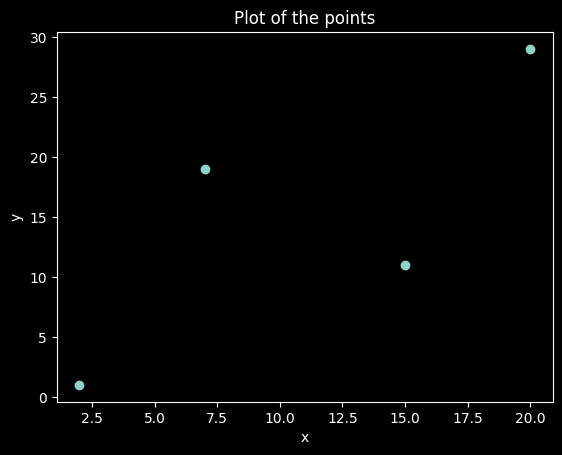

In [18]:
# for _, current_row in tqdm(result_interim_df.iterrows(), desc='Process_MATH', total=len(result_interim_df)):
skip = True
for _, current_row in tqdm(result_interim_df[result_interim_df['Messages'].isna()].iterrows(), desc='Process_MATH', total=len(result_interim_df[result_interim_df.Messages.isna()])):
    if skip:
        skip = False
        continue

    exp_id = current_row['Exp_ID']

    # Save in json files
    with open(os.path.join(MATH_DIR, f"{exp_id}.json"), 'r') as f:
        data = json.load(f)

    generated_output = current_row['Generated_Output']
    generated_output = remove_backslashes(generated_output)
    generated_output = generated_output.replace('</problem>', '</math_problem>')
    try:
        messages, CODE_TIMEOUT = convert_output_to_message_format(generated_output)
    except Exception:
        print(f"Error at {exp_id}")
        break
    
    data['Generated_Output'] = generated_output
    data['Messages'] = messages
    data['Code_Timeout'] = CODE_TIMEOUT

    with open(os.path.join(MATH_DIR, f"{exp_id}.json"), 'w') as f:
        json.dump(data, f, indent=4)

In [22]:
exp_ids = []
problems = []
hints = []
generated_outputs = []
messages = []
code_timeouts = []

for fname in tqdm(os.listdir(MATH_DIR)):

    # if len(fname) != len('Exp000000.json'):
    #     continue

    with open(os.path.join(MATH_DIR, fname), 'r') as f:
        data = json.load(f)

    if 'Generated_Output' not in data:
        continue
    
    try:
        exp_ids.append(data['Exp_ID'])
        problems.append(data['Problem'])
        # hints.append(data['Original_Solution'])
        hints.append(data['Solution'])
        generated_outputs.append(data['Generated_Output'])
        messages.append(data['Messages'])
        code_timeouts.append(data['Code_Timeout'])
    except Exception:
        print(f"Error at {data['Exp_ID']}")
        print(data.keys())
        break

final_MetaMath_df = pd.DataFrame({
    'Exp_ID': exp_ids,
    'Problem': problems,
    'Solution': hints,
    'Generated_Output': generated_outputs,
    'Messages': messages,
    'Code_Timeout': code_timeouts,
})

final_MetaMath_df.sort_values('Exp_ID', inplace=True, ignore_index=True)
final_MetaMath_df = final_MetaMath_df[~(final_MetaMath_df.Code_Timeout)]
final_MetaMath_df.reset_index(drop=True, inplace=True)
final_MetaMath_df

  0%|          | 0/4423 [00:00<?, ?it/s]

,Exp_ID,Problem,Solution,Generated_Output,Messages,Code_Timeout
0,Exp0000,"Let $$f(x) = \left\{\n\begin{array}{cl} ax+3, ...","For the piecewise function to be continuous, t...",<math_problem>Let $$f(x) = \left\{\n\begin{arr...,"[{'role': 'problem', 'content': 'Let $$f(x) = ...",False
1,Exp0001,A rectangular band formation is a formation wi...,Let $x$ be the number of band members in each ...,<math_problem>A rectangular band formation is ...,"[{'role': 'problem', 'content': 'A rectangular...",False
2,Exp0002,What is the degree of the polynomial $(4 +5x^3...,This polynomial is not written in standard for...,<math_problem>What is the degree of the polyno...,"[{'role': 'problem', 'content': 'What is the d...",False
3,Exp0003,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12...",<math_problem>Evaluate $\left\lceil3\left(6-\f...,"[{'role': 'problem', 'content': 'Evaluate $\le...",False
4,Exp0004,Sam is hired for a 20-day period. On days that...,Call $x$ the number of days Sam works and $y$ ...,<math_problem>Sam is hired for a 20-day period...,"[{'role': 'problem', 'content': 'Sam is hired ...",False
...,...,...,...,...,...,...
4397,Exp4417,"If $\det \mathbf{M} = -2,$ then find $ \det (\...",We have that $\det (\mathbf{M}^4) = (\det \mat...,"<math_problem>If $\det \mathbf{M} = -2,$ then ...","[{'role': 'problem', 'content': 'If $\det \mat...",False
4398,Exp4418,Find the smallest positive integer $k$ such th...,"First, we factor the given polynomial. The po...",<math_problem>Find the smallest positive integ...,"[{'role': 'problem', 'content': 'Find the smal...",False
4399,Exp4419,"Define the sequence $a_1, a_2, a_3, \ldots$ by...","By the product-to-sum formula,\n$$\sin \frac{1...","<math_problem>Define the sequence $a_1, a_2, a...","[{'role': 'problem', 'content': 'Define the se...",False
4400,Exp4420,Find the number of real solutions of the equat...,"Since $-1 \le \sin x \le 1,$ all solutions mus...",<math_problem>Find the number of real solution...,"[{'role': 'problem', 'content': 'Find the numb...",False


In [17]:
final_MetaMath_df.to_parquet('MetaMath.parquet', index=False)

ArrowInvalid: ('cannot mix list and non-list, non-null values', 'Conversion failed for column Messages with type object')

In [79]:
"""{{ bos_token }}
{% set step_counter = namespace(value=1) %}
{% for message in messages %}
    {% if (message['role'] == 'system') %}
        {{ message['content'] | trim + '\n' }}
    {% elif (message['role'] == 'problem') %}
        {{ '<math_problem>' + message['content'] | trim + '</math_problem>\n' }}
    {% elif (message['role'] == 'final_answer') %}
        {{ '<end_of_solution>\n<final_answer>' + message['content'] | trim + '</final_answer>' }}
    {% else %}
        {% if step_counter.value == 1 %}
            {{ '<start_of_solution>\n' }}
        {% endif %}
        {{ '<start_of_step>' + step_counter.value | string + '\n' }}
        {% for sub_message in message['content'] %}
            {% if (sub_message['role'] == 'text') %}
                {{ sub_message['content'] | trim }}
            {% elif (sub_message['role'] == 'code') %}
                {{ '<code_block>' + sub_message['content'] | trim + '</code_block>\n' }}
            {% elif (sub_message['role'] == 'code_output') %}
                {{ '<code_output_block>' + sub_message['content'] | trim + '</code_output_block>\n' }}
            {% endif %}
        {% endfor %}
        {{ '<end_of_step>\n' }}
        {% set step_counter.value = step_counter.value + 1 %}
    {% endif %}
{% endfor %}
{% if add_generation_prompt %}
    {{ '<start_of_step>' + step_counter.value|string + '\n' }}
{% endif %}"""

"{{ bos_token }}\n{% set step_counter = namespace(value=1) %}\n{% for message in messages %}\n    {% if (message['role'] == 'system') %}\n        {{ message['content'] | trim + '\n' }}\n    {% elif (message['role'] == 'problem') %}\n        {{ '<math_problem>' + message['content'] | trim + '</math_problem>\n' }}\n    {% elif (message['role'] == 'final_answer') %}\n        {{ '<end_of_solution>\n<final_answer>' + message['content'] | trim + '</final_answer>' }}\n    {% else %}\n        {% if step_counter.value == 1 %}\n            {{ '<start_of_solution>\n' }}\n        {% endif %}\n        {{ '<start_of_step>' + step_counter.value | string + '\n' }}\n        {% for sub_message in message['content'] %}\n            {% if (sub_message['role'] == 'text') %}\n                {{ sub_message['content'] | trim }}\n            {% elif (sub_message['role'] == 'code') %}\n                {{ '<code_block>' + sub_message['content'] | trim + '</code_block>\n' }}\n            {% elif (sub_message['ro

In [24]:
template = """{{ bos_token }}{% set step_counter = namespace(value=1) %}{% for message in messages %}{% if (message['role'] == 'system') %}{{ message['content'] | trim + '\n\n' }}{% elif (message['role'] == 'problem') %}{{ '<math_problem>' + message['content'] | trim + '</math_problem>\n' }}{% elif (message['role'] == 'final_answer') %}{{ '<end_of_solution>\n<final_answer>' + message['content'] | trim + '</final_answer>' }}{% else %}{% if step_counter.value == 1 %}{{ '<start_of_solution>\n' }}{% endif %}{{ '<start_of_step>' + step_counter.value | string + '\n' }}{% for sub_message in message['content'] %}{% if (sub_message['role'] == 'text') %}{{ sub_message['content'] | trim }}{% elif (sub_message['role'] == 'code') %}{{ '<code_block>' + sub_message['content'] | trim + '</code_block>\n' }}{% elif (sub_message['role'] == 'code_output') %}{{ '<code_output_block>' + sub_message['content'] | trim + '</code_output_block>\n' }}{% endif %}{% endfor %}{{ '<end_of_step>\n' }}{% set step_counter.value = step_counter.value + 1 %}{% endif %}{% endfor %}{% if add_generation_prompt %}{{ '<start_of_step>' + step_counter.value|string + '\n' }}{% endif %}"""

In [25]:
tokenizer = AutoTokenizer.from_pretrained('google/gemma-7b')
tokenizer.chat_template = template

In [26]:
print(tokenizer.apply_chat_template(final_MetaMath_df.Messages[0], tokenize=False).replace('<bos>', ''))

<math_problem>Let $$f(x) = \left\{
\begin{array}{cl} ax+3, &\text{ if }x>2, 
x-5 &\text{ if } -2 \le x \le 2, 
2x-b &\text{ if } x <-2.
\end{array}
\right.$$Find $a+b$ if the piecewise function is continuous (which means that its graph can be drawn without lifting your pencil from the paper).</math_problem>
<start_of_solution>
<start_of_step>1
For the piecewise function to be continuous, the cases must "meet" at $2$ and $-2$.
For example, $ax+3$ and $x-5$ must be equal when $x=2$. This implies<code_block>from sympy import symbols, Eq, solve

# Define symbols
a, x = symbols('a x')

# Define the equation
equation = Eq(a*x + 3, 2 - 5)

# Substitute x = 2 into the equation
equation = equation.subs(x, 2)

# Solve for a
solution = solve(equation, a)
# Print the solution
print(solution)</code_block>
<code_output_block>[-3]</code_output_block>
$a = -3$<end_of_step>
<start_of_step>2
Similarly, $x-5$ and $2x-b$ must be equal when $x=-2$. Solving,<code_block>from sympy import symbols, Eq, solve



In [27]:
sys_msg = [
    {'role': 'system', 'content': '''Your are a high school student appearing for your math exam.
You will be given a math problem to solve, and your job is to write the detailed step by step solution, with good mathematical reasoning and using python code for calculations, simplifications, solving equations, etc.

Format help and instructions:
- Problem has been given enclosed in <math_problem></math_problem> tags.
- Every step must be written within <start_of_step><end_of_step> tags.
- Code needs to be always written inside <code_block></code_block> tags - No backticks or triple backticks.
- Code output will be given in <code_output_block></code_output_block> tags.'''}
]

# final_MetaMath_df['']

In [28]:
print(tokenizer.apply_chat_template(sys_msg + final_MetaMath_df.Messages[0], tokenize=False).replace('<bos>', ''))

Your are a high school student appearing for your math exam.
You will be given a math problem to solve, and your job is to write the detailed step by step solution, with good mathematical reasoning and using python code for calculations, simplifications, solving equations, etc.

Format help and instructions:
- Problem has been given enclosed in <math_problem></math_problem> tags.
- Every step must be written within <start_of_step><end_of_step> tags.
- Code needs to be always written inside <code_block></code_block> tags - No backticks or triple backticks.
- Code output will be given in <code_output_block></code_output_block> tags.

<math_problem>Let $$f(x) = \left\{
\begin{array}{cl} ax+3, &\text{ if }x>2, 
x-5 &\text{ if } -2 \le x \le 2, 
2x-b &\text{ if } x <-2.
\end{array}
\right.$$Find $a+b$ if the piecewise function is continuous (which means that its graph can be drawn without lifting your pencil from the paper).</math_problem>
<start_of_solution>
<start_of_step>1
For the piecew

In [29]:
print(tokenizer.apply_chat_template(sys_msg + final_MetaMath_df.Messages[0], tokenize=False).replace('<bos>', '').split('<start_of_solution>\n'))

['Your are a high school student appearing for your math exam.\nYou will be given a math problem to solve, and your job is to write the detailed step by step solution, with good mathematical reasoning and using python code for calculations, simplifications, solving equations, etc.\n\nFormat help and instructions:\n- Problem has been given enclosed in <math_problem></math_problem> tags.\n- Every step must be written within <start_of_step><end_of_step> tags.\n- Code needs to be always written inside <code_block></code_block> tags - No backticks or triple backticks.\n- Code output will be given in <code_output_block></code_output_block> tags.\n\n<math_problem>Let $$f(x) = \\left\\{\n\\begin{array}{cl} ax+3, &\\text{ if }x>2, \nx-5 &\\text{ if } -2 \\le x \\le 2, \n2x-b &\\text{ if } x <-2.\n\\end{array}\n\\right.$$Find $a+b$ if the piecewise function is continuous (which means that its graph can be drawn without lifting your pencil from the paper).</math_problem>\n', '<start_of_step>1\nFo

In [30]:
exp_ids = []
prompts = []
completions = []

for _, current_row in tqdm(final_MetaMath_df.iterrows(), total=len(final_MetaMath_df)):

    exp_id = current_row['Exp_ID']
    try:
        prompt, completion = tokenizer.apply_chat_template(sys_msg + current_row['Messages'], tokenize=False).replace('<bos>', '').split('<start_of_solution>\n')
    except:
        # print(tokenizer.apply_chat_template(sys_msg + current_row['Messages'], tokenize=False).replace('<bos>', ''))
        print(f'Error at {exp_id}')
        continue
    prompt += '<start_of_solution>\n'

    exp_ids.append(exp_id)
    prompts.append(prompt)
    completions.append(completion)

final_MetaMath_df_v2 = pd.DataFrame({
    'exp_id': exp_ids,
    'prompt': prompts,
    'completion': completions
}
)

  0%|          | 0/4402 [00:00<?, ?it/s]

Error at Exp0161
Error at Exp2224
Error at Exp2789
Error at Exp2928
Error at Exp3600


In [31]:
final_MetaMath_df_v2

,exp_id,prompt,completion
0,Exp0000,Your are a high school student appearing for y...,<start_of_step>1\nFor the piecewise function t...
1,Exp0001,Your are a high school student appearing for y...,<start_of_step>1\nLet $x$ be the number of ban...
2,Exp0002,Your are a high school student appearing for y...,<start_of_step>1\nThe degree of a polynomial i...
3,Exp0003,Your are a high school student appearing for y...,<start_of_step>1\nWe have $3\left(6-\frac12\ri...
4,Exp0004,Your are a high school student appearing for y...,<start_of_step>1\nLet $x$ be the number of day...
...,...,...,...
4392,Exp4417,Your are a high school student appearing for y...,<start_of_step>1\nWe know that the determinant...
4393,Exp4418,Your are a high school student appearing for y...,"<start_of_step>1\nFirst, we factor the given p..."
4394,Exp4419,Your are a high school student appearing for y...,<start_of_step>1\nBy the product-to-sum formul...
4395,Exp4420,Your are a high school student appearing for y...,"<start_of_step>1\nSince $-1 \le \sin x \le 1,$..."


In [32]:
final_MetaMath_df_v2.to_parquet('Math.parquet', index=False)

In [33]:
df1 = pd.read_parquet('MetaMath.parquet')
df2 = pd.read_parquet('Math.parquet')

In [ ]:
1_00_000

In [40]:
ids = []
exp_ids = []
prompts = []
completions = []
prb_sources = []

dfs = [df1, df2]
sources = ['MetaMath', 'MATH']

idx = 0
cnt= 0
for df in dfs:
    source = sources[idx]
    for _, current_row in tqdm(df.iterrows(), total=len(df), desc=source):
        ids.append(f"SFT{cnt:0>6}")
        exp_ids.append(current_row['exp_id'])
        prompts.append(current_row['prompt'])
        completions.append(current_row['completion'])
        prb_sources.append(source)

        cnt += 1
    idx += 1

final_df = pd.DataFrame({
    'id': ids,
    'exp_id': exp_ids,
    "prompt": prompts,
    'completion': completions,
    'source': prb_sources
})
final_df

MetaMath:   0%|          | 0/136731 [00:00<?, ?it/s]

MATH:   0%|          | 0/4397 [00:00<?, ?it/s]

,id,exp_id,prompt,completion,source
0,SFT000000,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nEach player requires a $25 j...,MetaMath
1,SFT000001,Exp000001,Your are a high school student appearing for y...,"<start_of_step>1\nDiego baked $12$ cakes, and ...",MetaMath
2,SFT000002,Exp000002,Your are a high school student appearing for y...,<start_of_step>1\n$10101_3 = 1 \cdot 3^4 + 0 \...,MetaMath
3,SFT000003,Exp000003,Your are a high school student appearing for y...,<start_of_step>1\nWe know that every 30 minute...,MetaMath
4,SFT000004,Exp000004,Your are a high school student appearing for y...,<start_of_step>1\nThe area of the road is the ...,MetaMath
...,...,...,...,...,...
141123,SFT141123,Exp4417,Your are a high school student appearing for y...,<start_of_step>1\nWe know that the determinant...,MATH
141124,SFT141124,Exp4418,Your are a high school student appearing for y...,"<start_of_step>1\nFirst, we factor the given p...",MATH
141125,SFT141125,Exp4419,Your are a high school student appearing for y...,<start_of_step>1\nBy the product-to-sum formul...,MATH
141126,SFT141126,Exp4420,Your are a high school student appearing for y...,"<start_of_step>1\nSince $-1 \le \sin x \le 1,$...",MATH


In [42]:
ds = Dataset.from_pandas(final_df)

In [43]:
ds.push_to_hub(
    repo_id="Hrushi/SFT-MetaMath-MATH-TrainingData",
    commit_message='Initial Commit',
    private=True,
)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/142 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/Hrushi/SFT-MetaMath-MATH-TrainingData/commit/3ea9328a54c51fcfc06ec5b56f7c2f89f18795be', commit_message='Initial Commit', commit_description='', oid='3ea9328a54c51fcfc06ec5b56f7c2f89f18795be', pr_url=None, pr_revision=None, pr_num=None)

In [4]:
import signal
import functools
from time import sleep

class TimeoutExpired(Exception):
  """Custom exception for timeout"""
  pass

def timeout(seconds=10, error_message='Timeout'):
  """Decorator to timeout a function after a certain number of seconds.

  Args:
      seconds: The maximum number of seconds allowed for the function to run.
      error_message: The message to raise in case of timeout.

  Returns:
      The result of the decorated function if it finishes within the timeout,
      otherwise raises TimeoutExpired with the provided error message.
  """

  def decorator(func):
    @functools.wraps(func)  # Preserve function metadata
    def wrapper(*args, **kwargs):
      def _handle_timeout(signum, frame):
        raise TimeoutExpired(error_message)

      # Set the signal handler and a timer
      signal.signal(signal.SIGALRM, _handle_timeout)
      signal.alarm(seconds)

      try:
        result = func(*args, **kwargs)
      finally:
        # Cancel the alarm if the function finishes before timeout
        signal.alarm(0)
      return result
    return wrapper
  return decorator

In [5]:
# Example usage:
@timeout(seconds=5, error_message="Function took too long!")
def long_running_function(n):
  """Simulates a long-running function."""
  sleep(n)
  return n

# Test the function with and without timeout
try:
  print(long_running_function(3))  # This will finish
  print('Completed')
except TimeoutExpired as e:
  print(e)

try:
  print(long_running_function(10))  # This will timeout
except TimeoutExpired as e:
  print(e)

3
Completed
Function took too long!


## Process Rounds

In [9]:
def get_final_solution(x):
    sols = re.findall(r'\boxed\{(.*?)\}', x, re.DOTALL)

    if len(sols) == 0:
        sols = re.findall(r'\boxed (.*?)\$', x, re.DOTALL)
    
    # Check if all are same
    try:
        if all(sol == sols[0] for sol in sols):
            return sols[0]
        else:
            return sols[-1]
    except:
        print(sols)
        print(x)
        raise

MATH_df['final_answer'] = MATH_df['solution'].progress_apply(lambda x: get_final_solution(x))
MATH_df['final_answer_is_numeric'] = MATH_df['final_answer'].progress_apply(lambda x: x.isnumeric())

MATH_numeric_df = MATH_df[MATH_df['final_answer_is_numeric']].copy(deep=True).reset_index(drop=True)
MATH_numeric_df['ExpID'] = [f'Exp{idx:0>4}' for idx in range(len(MATH_numeric_df))]
MATH_numeric_df


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

,problem,level,type,solution,final_answer,final_answer_is_numeric,ExpID
0,How many vertical asymptotes does the graph of...,Level 3,Algebra,The denominator of the rational function facto...,2,True,Exp0000
1,What is the positive difference between $120\%...,Level 1,Algebra,One hundred twenty percent of 30 is $120\cdot3...,10,True,Exp0001
2,"If $2^8=4^x$, what is the value of $x$?",Level 1,Algebra,Rewrite $4$ as $2^2$ to find $4^x=2^{2x}$. Si...,4,True,Exp0002
3,What is the 100th term of the arithmetic seque...,Level 2,Algebra,"The common difference is $10 - 6 = 4$, so the ...",402,True,Exp0003
4,Mr. Madoff invests 1000 dollars in a fund that...,Level 4,Algebra,Let $r$ be the annual interest rate. Then aft...,7,True,Exp0004
...,...,...,...,...,...,...,...
2878,Given $\|\mathbf{v}\| = 5$ and $\|\mathbf{w}\|...,Level 3,Precalculus,Note that\n\begin{align*}\n\operatorname{proj}...,5,True,Exp2878
2879,If $0^\circ < x < 180^\circ$ and $\cos x + \si...,Level 5,Precalculus,"From the given equation, $\cos x = \frac{1}{2}...",14,True,Exp2879
2880,"Let $x_1,$ $x_2,$ $x_3,$ $y_1,$ $y_2,$ and $y_...",Level 5,Precalculus,"In general,\n\[\frac{1}{2} \begin{vmatrix} x_1...",144,True,Exp2880
2881,Compute\n\[\frac{1}{\cos^2 10^\circ} + \frac{1...,Level 4,Precalculus,We can write\n\begin{align*}\n\frac{1}{\cos^2 ...,12,True,Exp2881


In [11]:
final_answers = {}
FPATH = os.path.join('..', 'data', 'Rounds')
for fname in tqdm(os.listdir(FPATH)):
    df = pd.read_json(os.path.join(FPATH, fname), lines=True, orient='records')
    for _, row in df[df['Final_Answer'].notna()].iterrows():
        exp_id = row.ExpID
        fa = row.Final_Answer

        if exp_id in final_answers:
            final_answers[exp_id]['fas'].append(str(fa))
        else:
            final_answers[exp_id] = {
                'fas': [fa],
                'fa': None,
                'top3': []
            }
    
    print(f'{fname.split(".")[0]}: {len(final_answers): >4}/{len(MATH_numeric_df)}')

  0%|          | 0/25 [00:00<?, ?it/s]

Round01: 1580/2883
Round02: 2363/2883
Round03: 2378/2883
Round04: 2378/2883
Round05: 2378/2883
Round06: 2378/2883
Round07: 2378/2883
Round08: 2378/2883
Round09: 2378/2883
Round10: 2378/2883
Round11: 2378/2883
Round12: 2378/2883
Round13: 2378/2883
Round14: 2378/2883
Round15: 2378/2883
Round16: 2378/2883
Round17: 2378/2883
Round18: 2378/2883
Round19: 2378/2883
Round20: 2378/2883
Round21: 2378/2883
Round22: 2378/2883
Round23: 2378/2883
Round24: 2378/2883
Round25: 2378/2883


In [13]:
from collections import Counter

In [17]:
ncorrect = 0
nwrong = 0
ntop3 = 0

for exp_id in tqdm(final_answers):
    fas = final_answers[exp_id]['fas']
    top3 = [str(x) for x, _ in Counter(fas).most_common(3)]
    fa, _ = Counter(fas).most_common(1)[0]
    ofa = str(MATH_numeric_df[MATH_numeric_df['ExpID'] == exp_id].final_answer.values[0])

    final_answers[exp_id]['top3'] = top3
    final_answers[exp_id]['fa'] = fa
    final_answers[exp_id]['ofa'] = ofa

    if fa == ofa:
        ncorrect +=1
    else:
        nwrong += 1

    if ofa in top3:
        ntop3 += 1

nwrong += len(MATH_numeric_df) - len(final_answers)

print(f'Total Problems\t\t: {len(MATH_numeric_df)}')
print(f"Correct Answers\t\t: {ncorrect} ({round(ncorrect / len(MATH_numeric_df) * 100, 2)}%)")
print(f"Incorrect Answers\t: {nwrong} ({round(nwrong / len(MATH_numeric_df) * 100, 2)}%)")
print(f"Top3 Answer\t\t: {ntop3} ({round(ntop3 / len(MATH_numeric_df) * 100, 2)}%)")

  0%|          | 0/2378 [00:00<?, ?it/s]

Total Problems		: 2883
Correct Answers		: 389 (13.49%)
Incorrect Answers	: 2494 (86.51%)
Top3 Answer		: 649 (22.51%)


In [52]:
final_raw_df = pd.concat([final_df_1, MATH_df], ignore_index=True)
final_raw_df

,type,query,original_question,response,final_answer,final_answer_is_numeric,problem,level,solution
0,MATH_AnsAug,Gracie and Joe are choosing numbers on the com...,Gracie and Joe are choosing numbers on the com...,"The distance between two points $(x_1,y_1)$ an...",\sqrt{5},False,NaN,NaN,NaN
1,GSM_Rephrased,What is the total cost of purchasing equipment...,The treasurer of a football team must buy equi...,"Each player requires a $25 jersey, a $15.20 pa...",752,True,NaN,NaN,NaN
2,GSM_SV,Diego baked 12 cakes for his sister's birthday...,Diego baked 12 cakes for his sister's birthday...,"To solve this problem, we need to determine th...",1,True,NaN,NaN,NaN
3,MATH_AnsAug,Convert $10101_3$ to a base 10 integer.,Convert $10101_3$ to a base 10 integer.,$10101_3 = 1 \cdot 3^4 + 0 \cdot 3^3 + 1 \cdot...,91,True,NaN,NaN,NaN
4,GSM_FOBAR,"Sue works in a factory and every 30 minutes, a...","Sue works in a factory and every 30 minutes, a...","We know that every 30 minutes, a machine produ...",1,True,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
153611,Precalculus,NaN,NaN,NaN,63,True,Find the number of real solutions of the equat...,Level 3,"Since $-1 \le \sin x \le 1,$ all solutions mus..."
153612,Precalculus,NaN,NaN,NaN,0,True,"Let $A,$ $B,$ $C$ be the angles of a triangle....",Level 2,We can expand the determinant as follows:\n\be...
153613,Precalculus,NaN,NaN,NaN,3,True,"Let $G$ be the centroid of triangle $ABC,$ and...",Level 2,"Let $\mathbf{a}$ denote $\overrightarrow{A},$ ..."
153614,Precalculus,NaN,NaN,NaN,-\frac{\sqrt{7,False,If angle $A$ lies in the second quadrant and $...,Level 2,"Since angle $A$ lies in the second quadrant, $..."


In [53]:
exp_ids = []
problems = []
solutions = []
fas = []
prb_types = []

cnt = 0
for _, row in tqdm(final_raw_df.iterrows(), total=(len(final_raw_df))):

    exp_id = f"Exp{cnt:0>6}"

    if isinstance(row.query, str):
        problem = row.query
    else:
        problem = row.problem
    
    if isinstance(row.response, str):
        solution = row.response
    else:
        solution = row.solution
    
    prb_type = row.type
    fa = row.final_answer

    exp_ids.append(exp_id)
    problems.append(problem)
    solutions.append(solution)
    prb_types.append(prb_type)
    fas.append(fa)
    cnt += 1

final_df = pd.DataFrame({
    "ExpID": exp_ids,
    "Type": prb_types,
    "Problem": problems,
    "Solution": solutions,
    'FinalAnswer': fas,
})

final_df

  0%|          | 0/153616 [00:00<?, ?it/s]

,ExpID,Type,Problem,Solution,FinalAnswer
0,Exp000000,MATH_AnsAug,Gracie and Joe are choosing numbers on the com...,"The distance between two points $(x_1,y_1)$ an...",\sqrt{5}
1,Exp000001,GSM_Rephrased,What is the total cost of purchasing equipment...,"Each player requires a $25 jersey, a $15.20 pa...",752
2,Exp000002,GSM_SV,Diego baked 12 cakes for his sister's birthday...,"To solve this problem, we need to determine th...",1
3,Exp000003,MATH_AnsAug,Convert $10101_3$ to a base 10 integer.,$10101_3 = 1 \cdot 3^4 + 0 \cdot 3^3 + 1 \cdot...,91
4,Exp000004,GSM_FOBAR,"Sue works in a factory and every 30 minutes, a...","We know that every 30 minutes, a machine produ...",1
...,...,...,...,...,...
153611,Exp153611,Precalculus,Find the number of real solutions of the equat...,"Since $-1 \le \sin x \le 1,$ all solutions mus...",63
153612,Exp153612,Precalculus,"Let $A,$ $B,$ $C$ be the angles of a triangle....",We can expand the determinant as follows:\n\be...,0
153613,Exp153613,Precalculus,"Let $G$ be the centroid of triangle $ABC,$ and...","Let $\mathbf{a}$ denote $\overrightarrow{A},$ ...",3
153614,Exp153614,Precalculus,If angle $A$ lies in the second quadrant and $...,"Since angle $A$ lies in the second quadrant, $...",-\frac{\sqrt{7


In [54]:
final_df.to_parquet('AIMO-Math-Problems.parquet', index=False)

## Playing with Training Data

In [55]:
ds = load_dataset('Hrushi/SFT-MetaMath-MATH-TrainingData')['train']
df = ds.to_pandas()
df

Generating train split:   0%|          | 0/141128 [00:00<?, ? examples/s]

,id,exp_id,prompt,completion,source
0,SFT000000,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nEach player requires a $25 j...,MetaMath
1,SFT000001,Exp000001,Your are a high school student appearing for y...,"<start_of_step>1\nDiego baked $12$ cakes, and ...",MetaMath
2,SFT000002,Exp000002,Your are a high school student appearing for y...,<start_of_step>1\n$10101_3 = 1 \cdot 3^4 + 0 \...,MetaMath
3,SFT000003,Exp000003,Your are a high school student appearing for y...,<start_of_step>1\nWe know that every 30 minute...,MetaMath
4,SFT000004,Exp000004,Your are a high school student appearing for y...,<start_of_step>1\nThe area of the road is the ...,MetaMath
...,...,...,...,...,...
141123,SFT141123,Exp4417,Your are a high school student appearing for y...,<start_of_step>1\nWe know that the determinant...,MATH
141124,SFT141124,Exp4418,Your are a high school student appearing for y...,"<start_of_step>1\nFirst, we factor the given p...",MATH
141125,SFT141125,Exp4419,Your are a high school student appearing for y...,<start_of_step>1\nBy the product-to-sum formul...,MATH
141126,SFT141126,Exp4420,Your are a high school student appearing for y...,"<start_of_step>1\nSince $-1 \le \sin x \le 1,$...",MATH


In [56]:
def replace_second_occurrence(text):  # noqa: F811
    parts = text.split("<math_problem>", 2)
    if len(parts) < 3:
        return text  # No replacement needed
    return "<math_problem>".join(parts[:2]) + "</math_problem>" + parts[2]


def replace_nth_occurrence(text, old, new, n):  # noqa: F811
    parts = text.split(old, n)
    if len(parts) < n + 1:
        return text  # No replacement needed
    return old.join(parts[:n]) + new + parts[n]


unicode_remapping = {
    "≅": r"\cong",
    "≠": r"\neq",
    "≡": r"\equiv",
    "≤": r"\leq",
    "≥": r"\geq",
    "⊥": r"\perp",
    "⊂": r"\subset",
    "⊆": r"\subseteq",
    "⊇": r"\supseteq",
    "⊕": r"\oplus",
    "⊗": r"\otimes",
    "∩": r"\cap",
    "∴": r"\therefore",
    "”": r"\"",
    "‘": r"'",
    "“": r"\"",
    "\xad": r"-",
    "–": r"-",
    "º": r"\degree",
    "°": r"\degree",
    "θ": r"\theta",
    "∞": r"\infty",
    "□": r"\square",
    "Σ": r"\Sigma",
    "…": r"\cdots",
    "³": r"^3",
    "′": r"'",
    "⇒": r"\implies",
    "×": r"\times",
    "Δ": r"\Delta",
    "σ": r"\sigma",
    "∆": r"\Delta",
    "÷": r"\div",
    "☐": r"\square",
    "Φ": r"\phi",
    "∠": r"\angle",
    "∵": r"\because",
    "±": r"\pm",
    "↔": r"\Leftrightarrow",
    "π": r"\pi",
    "²": r"^2",
    "μ": r"\mu",
    "≈": r"\approx",
    "₹": r"Rs.",
    "’": r"'",
}

new_unicode_remapping = {
    "\u2245": r"\cong",
    "\u22a5": r"\perp",
    "\u2229": r"\cap",
    "\u2234": r"\therefore",
    "\u201d": r"\"",
    "\u2018": r"'",
    "\u201c": r"\"",
    "\xad": r"-",
    "\xba": r"\degree",
    "\u2260": r"\neq",
    "\u03b8": r"\theta",
    "\u221e": r"\infty",
    "\u25a1": r"\square",
    "\u03a3": r"\Sigma",
    "\u2026": r"\cdots",
    "\xb3": r"^3",
    "\xb0": r"\degree",
    "\u2032": r"'",
    "\u21d2": r"\implies",
    "\xd7": r"\times",
    "\u0394": r"\Delta",
    "\u03c3": r"\sigma",
    "\u2206": r"\Delta",
    "\xf7": r"\div",
    "\u2610": r"\square",
    "\u2265": r"\geq",
    "\u03a6": r"\phi",
    "\u2220": r"\angle",
    "\u2235": r"\because",
    "\xb1": r"\pm",
    "\u2194": r"\Leftrightarrow",
    "\u03c0": r"\pi",
    "\xb2": r"^2",
    "\u2013": r"-",
    "\u03bc": r"\mu",
    "\u2248": r"\approx",
    "\u20b9": r"Rs.",
    "\u2264": r"\leq",
    "\u2019": r"'",
    "\u2212": r"-",
}

python_repl = PythonREPL()

In [57]:
class TimeOutException(Exception):  # noqa: F811
   pass

def timeout(seconds=None):
    """
    Decorator to apply a timeout to a function.

    Args:
        seconds (int, optional): Timeout duration in seconds. If None, no timeout is applied.
                                  Defaults to None.

    Raises:
        TimeoutException: If the decorated function exceeds the specified timeout.

    Returns:
        function: Decorated function.
    """

    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            if seconds is None:
                # No timeout, just call the function directly
                return func(*args, **kwargs)

            result = None

            def target():
                nonlocal result
                try:
                    result = func(*args, **kwargs)
                except Exception as e:
                    result = e  # Store any exceptions raised by the function

            thread = threading.Thread(target=target)
            thread.start()
            thread.join(timeout=seconds)

            if thread.is_alive():
                raise TimeOutException(f"Function call timed out after {seconds} seconds")

            if isinstance(result, Exception):
                raise result  # Reraise any exceptions from the function

            return result

        return wrapper

    return decorator

In [58]:
@timeout(10)
def run_python_repl(code:str) -> str:  # noqa: F811

    return python_repl.run(code).strip()

In [59]:
def get_python_output(code:str):  # noqa: F811

    try:
        output = run_python_repl(code)
    except TimeOutException:
        output = "TimeoutError"

    return output

In [71]:
def get_messages_v2(parsed_text: str, verbose: bool = False) -> Tuple[List[Dict[str, str]], bool]:  # noqa: F811
    messages = []

    # Extract the Problem
    problem = re.search(
        r"<math_problem>(.*)</math_problem>", parsed_text, re.DOTALL
    ).group(1)
    messages.append({"role": "problem", "content": problem.strip()})

    # Extract all the Steps
    steps = re.findall(
        r"<start_of_step>\d+\n(.*?)<end_of_step>", parsed_text, re.DOTALL
    )

    # Extract the incomplete step
    if parsed_text.count("<code_block") < parsed_text.count("<code_block>"):
        start_index = parsed_text.rfind("<start_of_step>")
        incomplete_step = re.search(
            r"<start_of_step>\d+\n(.*)</code_block>",
            parsed_text[start_index:],
            re.DOTALL,
        ).group(1)
        steps.append(incomplete_step + "</code_block>")

    if verbose:
        print(f"\n{'=='*50}\nFound {len(steps)} Steps")
        print(steps)

    CODE_TIMEOUT = False
    for step in steps:
        # Extract the text before the code block
        if "<code_block>" not in step:
            messages.append(
                {"role": "step", "content": [{"role": "text", "content": step.strip()}]}
            )
            continue
        else:
            text_before_code = re.search(
                r"(.*)<code_block>", step, re.DOTALL
            ).group(1)

            if "</code_output_block>" in step:
                text_after_code = re.search(
                    r"</code_output_block>(.*)", step, re.DOTALL
                ).group(1)
                text_after_code = (
                    None if text_after_code.strip() == "" else text_after_code
                )
            else:
                text_after_code = None
            code = re.findall(r"<code_block>(.*)</code_block>", step, re.DOTALL)

            assert isinstance(code, list)

            if len(code) > 1:
                print('Multiple Code Blocks')
                raise Exception
            
            # print(code)
            code = code[0]
            

            if verbose:
                print(f"Text Before Code: {text_before_code}")
                print(f"Text After Code: {text_after_code}")
                print(f"Code: {code}")

            messages.append(
                {
                    "role": "step",
                    "content": [
                        {"role": "text", "content": text_before_code.strip()},
                        {"role": "code", "content": code.strip()},
                        {"role": "code_output","content": get_python_output(code)},
                    ],
                }
            )

            if 'TimeoutError' in messages[-1]['content'][-1]['content']:
                CODE_TIMEOUT = True

            if text_after_code is not None:
                if text_after_code.strip() != "":
                    messages[-1]["content"].append({"role": "text", "content": text_after_code.strip()})

    # Final Answer
    if "<final_answer>" in parsed_text:
        final_answer = re.search(
            r"<final_answer>(.*?)</final_answer>", parsed_text, re.DOTALL
        ).group(1)
        messages.append({"role": "final_answer", "content": final_answer.strip()})

    return messages, CODE_TIMEOUT

In [72]:
def convert_output_to_message_format(parsed_text: str, verbose: bool = False) -> Tuple[List[Dict[str, str]], bool]:
    # Remove Excess space after step number if any
    parsed_text = re.sub(r"(<start_of_step>\d+)\s+", r"\1\n", parsed_text, re.DOTALL)

    # Replace Unicode Characters, if any
    for key, value in new_unicode_remapping.items():
        parsed_text = parsed_text.replace(key, value)

    # # <math_problem> appears twice in the text, then replace only the second occurence with </math_problem> tag
    # if parsed_text.count("<math_problem>") > 1:
    #     parsed_text = replace_nth_occurrence(
    #         parsed_text, "<math_problem>", "</math_problem>", 2
    #     )

    # if parsed_text.count("</code_input_block>") > 1:
    #     parsed_text = replace_nth_occurrence(
    #         parsed_text, "</code_input_block>", "<code_input_block>", 1
    #     )

    # if (
    #     parsed_text.count("<code_input_block>") == 0
    #     and parsed_text.count("</code_input_block>") == 1
    # ):
    #     parsed_text = parsed_text.replace("</code_input_block>", "<end_of_step>")

    # if "</start_of_step>" in parsed_text:
    #     parsed_text = parsed_text.replace("</start_of_step>", "<end_of_step>")

    # if parsed_text.count("<math_problem>") > 1:
    #     parsed_text = replace_second_occurrence(parsed_text)

    if verbose:
        print(parsed_text)
    # print(repr(parsed_text))
    return get_messages_v2(parsed_text, verbose)

In [67]:
system_prompt = """Your are a high school student appearing for your math exam.
You will be given a math problem to solve, and your job is to write the detailed step by step solution, with good mathematical reasoning and using python code for calculations, simplifications, solving equations, etc.

Format help and instructions:
- Problem has been given enclosed in <math_problem></math_problem> tags.
- Every step must be written within <start_of_step><end_of_step> tags.
- Code needs to be always written inside <code_block></code_block> tags - No backticks or triple backticks.
- Code output will be given in <code_output_block></code_output_block> tags.
"""

In [74]:
idx = 1234
text = df.prompt[idx] + df.completion[idx]
text = text.replace(system_prompt, '')
print(text)


<math_problem>If Droid, the owner of a coffee shop, uses 3 bags of coffee beans every morning, triple that amount in the afternoon, and twice the morning amount in the evening, how many bags of coffee beans does he use in a week?</math_problem>
<start_of_solution>
<start_of_step>1
In the morning, Droid uses 3 bags of coffee beans.<end_of_step>
<start_of_step>2
Triple that amount in the afternoon means he uses $3 \times 3 =$<code_block>print(3 * 3)</code_block>
<code_output_block>9</code_output_block>
bags of coffee beans.<end_of_step>
<start_of_step>3
And twice the morning amount in the evening means he uses $3 \times 2 =$<code_block>print(3 * 2)</code_block>
<code_output_block>6</code_output_block>
bags of coffee beans.<end_of_step>
<start_of_step>4
So, in one day, Droid uses a total of $3 + 9 + 6 =$<code_block>print(3 + 9 + 6)</code_block>
<code_output_block>18</code_output_block>
bags of coffee beans.<end_of_step>
<start_of_step>5
Since there are 7 days in a week, Droid uses a tota

In [75]:
msgs, _ = convert_output_to_message_format(text)
msgs

[{'role': 'problem',
  'content': 'If Droid, the owner of a coffee shop, uses 3 bags of coffee beans every morning, triple that amount in the afternoon, and twice the morning amount in the evening, how many bags of coffee beans does he use in a week?'},
 {'role': 'step',
  'content': [{'role': 'text',
    'content': 'In the morning, Droid uses 3 bags of coffee beans.'}]},
 {'role': 'step',
  'content': [{'role': 'text',
    'content': 'Triple that amount in the afternoon means he uses $3 \\times 3 =$'},
   {'role': 'code', 'content': 'print(3 * 3)'},
   {'role': 'code_output', 'content': '9'},
   {'role': 'text', 'content': 'bags of coffee beans.'}]},
 {'role': 'step',
  'content': [{'role': 'text',
    'content': 'And twice the morning amount in the evening means he uses $3 \\times 2 =$'},
   {'role': 'code', 'content': 'print(3 * 2)'},
   {'role': 'code_output', 'content': '6'},
   {'role': 'text', 'content': 'bags of coffee beans.'}]},
 {'role': 'step',
  'content': [{'role': 'text'

In [77]:
tokenizer = AutoTokenizer.from_pretrained('Hrushi/AIMO-SFT-DDP-Merged-Gemma-7B-N141128-E1-R128-A64')
tokenizer.chat_template

tokenizer_config.json:   0%|          | 0.00/41.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/918 [00:00<?, ?B/s]

"{{ bos_token }}{% set step_counter = namespace(value=1) %}{% for message in messages %}{% if (message['role'] == 'system') %}{{ message['content'] | trim + '\n\n' }}{% elif (message['role'] == 'problem') %}{{ '<math_problem>' + message['content'] | trim + '</math_problem>\n' }}{% elif (message['role'] == 'final_answer') %}{{ '<end_of_solution>\n<final_answer>' + message['content'] | trim + '</final_answer>' }}{% else %}{% if step_counter.value == 1 %}{{ '<start_of_solution>\n' }}{% endif %}{{ '<start_of_step>' + step_counter.value | string + '\n' }}{% for sub_message in message['content'] %}{% if (sub_message['role'] == 'text') %}{{ sub_message['content'] | trim }}{% elif (sub_message['role'] == 'code') %}{{ '<code_block>' + sub_message['content'] | trim + '</code_block>\n' }}{% elif (sub_message['role'] == 'code_output') %}{{ '<code_output_block>'  + sub_message['content'] | trim + '</code_output_block>\n' }}{% endif %}{% endfor %}{{ '<end_of_step>\n' }}{% set step_counter.value = st

In [87]:
print(tokenizer.apply_chat_template([msgs[6]], tokenize=False).replace(tokenizer.bos_token, '').replace('<start_of_solution>', '').strip())

<end_of_solution>
<final_answer>126</final_answer>


  0%|          | 0/141128 [00:00<?, ?it/s]

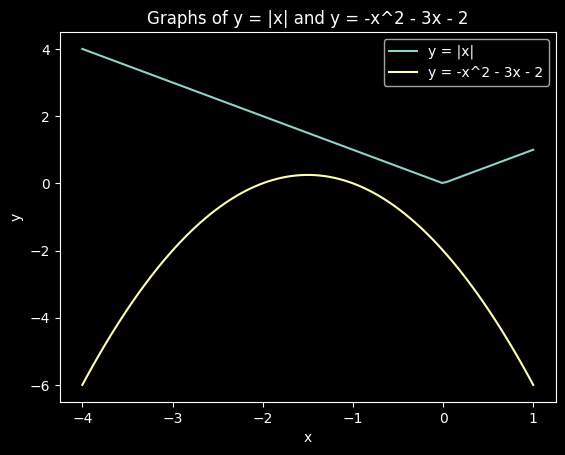

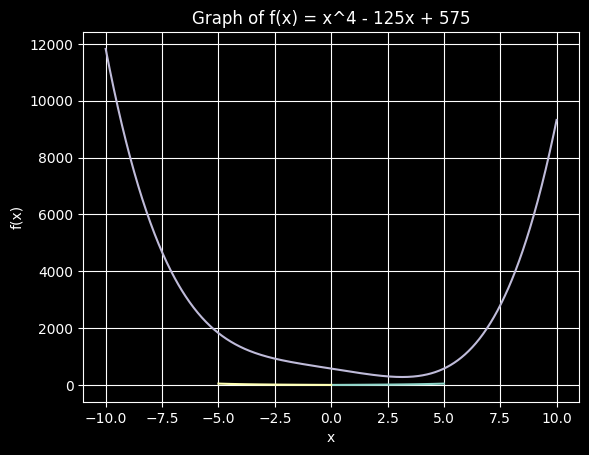

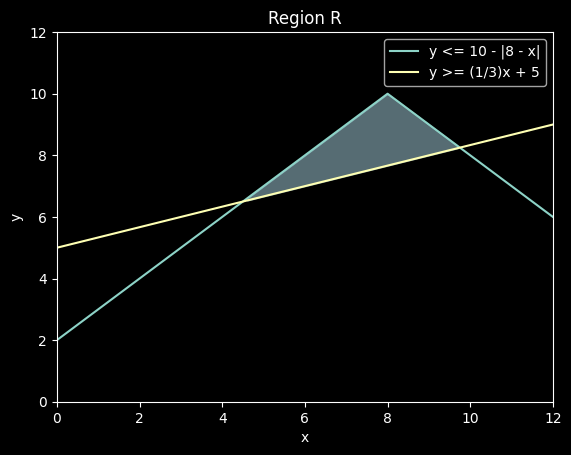

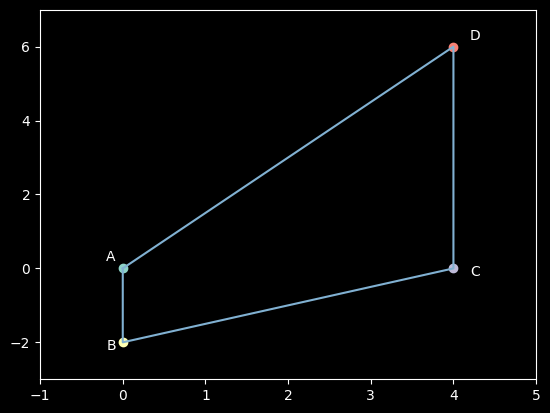

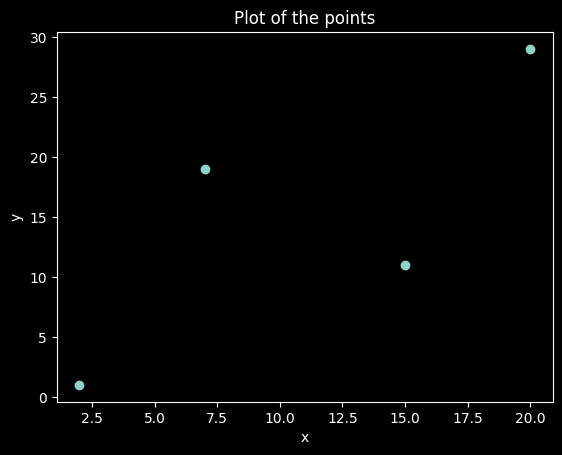

,SFT_ID,MSG_ID,MSG
0,SFT000003,3,<start_of_step>3\nWe are given that the total ...
1,SFT000004,3,<start_of_step>3\nThe cost of each truckload i...
2,SFT000004,4,<start_of_step>4\nThe sales tax is $20\%$ of t...
3,SFT000004,5,<start_of_step>5\nThe total cost including sal...
4,SFT000004,6,<start_of_step>6\nWe are given that the total ...
...,...,...,...
260609,SFT141126,3,<start_of_step>3\nWe see that on the interval ...
260610,SFT141127,1,<start_of_step>1\nWe can expand the determinan...
260611,SFT141127,2,"<start_of_step>2\nIn general,\n\begin{align*}\..."
260612,SFT141127,3,"<start_of_step>3\nNow,\n\begin{align*}\n\sin^3..."


In [109]:
sft_ids = []
msg_ids = []
messages = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    # Get id
    sft_id = row.id

    # Get text
    text = row.prompt + row.completion
    text = text.replace(system_prompt, '')

    # Extract Messages
    msgs, _ = convert_output_to_message_format(text)

    for idx in range(len(msgs)):

        msg = msgs[idx]

        if msg['role'] != 'step':
            continue

        msg_text = tokenizer.apply_chat_template([msg], tokenize=False).replace(tokenizer.bos_token, '').replace('<start_of_solution>', '').strip()
        msg_text = re.sub(r"<start_of_step>(\d+)\n", fr"<start_of_step>{idx}\n", msg_text)

        if '<code_block>' not in msg_text:
            sft_ids.append(sft_id)
            msg_ids.append(idx)
            messages.append(msg_text)

steps_df = pd.DataFrame(
    {
        'SFT_ID': sft_ids,
        'MSG_ID': msg_ids,
        'MSG': messages,
    }
)
steps_df

In [183]:
idx = 260609
print(steps_df.MSG[idx])

<start_of_step>3
We see that on the interval $[2 \pi k, 2 \pi (k + 1)],$ where $0 \le k \le 15,$ the graphs of $y = \frac{x}{100}$ and $y = \sin x$ intersect twice.  Thus, there are $2 \cdot 16 = 32$ solutions for $0 \le x \le 100.$<end_of_step>


$$= \frac{2 \cdot 3 \cdot 4 \dotsm (n+1) \dotsm 502}{1 \cdot 2 \cdot 3 \dotsm n \dotsm 501}$$

In [162]:
# print(df[df['id'] == steps_df.SFT_ID[idx]].completion.values[0])

In [ ]:
examples = [
    {
        'original': '<start_of_step>1\nWe are given that the total number of cans of soda produced is 480, so we can write: $480 = 480 \times x$.<end_of_step>',
        'updated': 'SAME'
    },
    {
        'original': """<start_of_step>1\nThe sales tax is $20\%$ of the total cost, so the sales tax amount is $0.2 \times (50 \times x) = 10 \times x$ dollars.<end_of_step>""",
        'updated': """<start_of_step>1\nThe sales tax is $20\%$ of the total cost, so the sales tax amount is $0.2 \times (50 \times x) =$ dollars.\n<code_block>from sympy import Symbol\n\nx = Symbol('x')\nsales_tax_rate = 0.2\ntotal_cost = 50 * x\n\nsales_tax_amount = sales_tax_rate * total_cost\n\nprint(sales_tax_amount)</code_block>\n<code_output_block>10.0*x</code_output_block>\nHence, the sales tax amount is $10 \times x$ dollars.\n<end_of_step>"""
    },
    {
        'original': "<start_of_step>1\nWe know that Evan's dog weighs $63$ pounds.\nWe also know that Evan's dog weighs $x$ times as much as Ivan's dog, which means Ivan's dog weighs $63/x$ pounds.<end_of_step>",
        'updated': 'SAME'
    },
    {
        'original': "<start_of_step>1\nSimplifying, we get $\binom{14}{11} = \dfrac{14!}{11!3!}$.<end_of_step>",
        "updated": "<start_of_step>1\nThe sales tax is $20\%$ of the total cost, so the sales tax amount is $0.2 \times (50 \times x) =$ dollars.\n<code_block>from sympy import Symbol\n\nx = Symbol('x')\nsales_tax_rate = 0.2\ntotal_cost = 50 * x\n\nsales_tax_amount = sales_tax_rate * total_cost\n\nprint(sales_tax_amount)</code_block>\n<code_output_block>\n10.0*x\n</code_output_block>\nHence, the sales tax amount is $10 \times x$ dollars.\n<end_of_step>"
    }
]

In [103]:
"""<start_of_step>1
Simplifying, we get $\binom{14}{11} =$.
<code_block>from sympy import binomial

result = binomial(14, 11)
print(result)</code_block>
<code_output_block>364.0</code_output_block>
Hence, $\binom{14}{11} = 364$.
<end_of_step>"""

"<start_of_step>1\nThe sales tax is $20\\%$ of the total cost, so the sales tax amount is $0.2 \times (50 \times x) =$ dollars.\n<code_block>from sympy import Symbol\n\nx = Symbol('x')\nsales_tax_rate = 0.2\ntotal_cost = 50 * x\n\nsales_tax_amount = sales_tax_rate * total_cost\n\nprint(sales_tax_amount)</code_block>\n<code_output_block>\n10.0*x\n</code_output_block>\nHence, the sales tax amount is $10 \times x$ dollars.\n<end_of_step>"

## Fintuned Outputs

In [55]:
FT_FPATH = os.path.join(ROOT_DATA_DIR, 'FT-Outputs')
os.path.exists(FT_FPATH)

True

In [56]:
problems_df = pd.read_parquet('AIMO-Math-Problems.parquet')
problems_df

,ExpID,Type,Problem,Solution,FinalAnswer
0,Exp000000,MATH_AnsAug,Gracie and Joe are choosing numbers on the com...,"The distance between two points $(x_1,y_1)$ an...",\sqrt{5}
1,Exp000001,GSM_Rephrased,What is the total cost of purchasing equipment...,"Each player requires a $25 jersey, a $15.20 pa...",752
2,Exp000002,GSM_SV,Diego baked 12 cakes for his sister's birthday...,"To solve this problem, we need to determine th...",1
3,Exp000003,MATH_AnsAug,Convert $10101_3$ to a base 10 integer.,$10101_3 = 1 \cdot 3^4 + 0 \cdot 3^3 + 1 \cdot...,91
4,Exp000004,GSM_FOBAR,"Sue works in a factory and every 30 minutes, a...","We know that every 30 minutes, a machine produ...",1
...,...,...,...,...,...
153611,Exp153611,Precalculus,Find the number of real solutions of the equat...,"Since $-1 \le \sin x \le 1,$ all solutions mus...",63
153612,Exp153612,Precalculus,"Let $A,$ $B,$ $C$ be the angles of a triangle....",We can expand the determinant as follows:\n\be...,0
153613,Exp153613,Precalculus,"Let $G$ be the centroid of triangle $ABC,$ and...","Let $\mathbf{a}$ denote $\overrightarrow{A},$ ...",3
153614,Exp153614,Precalculus,If angle $A$ lies in the second quadrant and $...,"Since angle $A$ lies in the second quadrant, $...",-\frac{\sqrt{7


In [57]:
fnames = os.listdir(FT_FPATH)
fnames[0]

'Exp00000.jsonl'

In [70]:
def post_process_math_expr(raw_fa:str) -> str:
    if 'text' in rf"{raw_fa}" or 'text' in raw_fa or 'ext\{' in raw_fa:
        return raw_fa
    
    try:
        new_fas = parse_expr(raw_fa)
    except Exception:
        try:
            new_fas = parse_latex(raw_fa)
        except Exception:
            new_fas = raw_fa
    
    try:
        new_fas = str(new_fas)
    except Exception:
        new_fas = None

    return new_fas


In [108]:
dfs = []

for fname in tqdm(fnames):
    test_df = pd.read_json(os.path.join(FT_FPATH, fname), lines=True, orient='records')

    search_expid = fname.replace('Exp', '').replace('.jsonl', '')
    search_expid = f'Exp{search_expid:0>6}'
    ofa = problems_df[problems_df['ExpID'] == search_expid].FinalAnswer.values[0]

    test_df['exp_id'] = [search_expid for _ in range(len(test_df))]
    test_df['ofa'] = [ofa for _ in range(len(test_df))]
    # test_df['correct_answer'] = test_df.progress_apply(lambda x: post_process_math_expr(x.final_answer) == post_process_math_expr(x.ofa), axis=1)
    # test_df['final_answer'] = test_df.progress_apply(lambda x: x.ofa if x.correct_answer else x.final_answer, axis=1)
    # test_df['code_used'] = test_df['solution'].progress_apply(lambda x: x.count('<code_block>') > 1)
    # test_df['image_used'] = test_df['solution'].progress_apply(lambda x: x.count('matplotlib') > 0 or x.count('image') > 0)
    test_df['is_correct'] = test_df.apply(lambda x: post_process_math_expr(str(x.final_answer)) == post_process_math_expr(str(x.ofa)), axis=1)
    test_df['final_answer'] = test_df.apply(lambda x: x.ofa if x.is_correct else x.final_answer, axis=1)
    test_df['is_code_used'] = test_df['solution'].apply(lambda x: x.count('<code_block>') > 1)
    test_df['is_image_used'] = test_df.apply(lambda x: (x['solution'].count('matplotlib') > 0 or x['solution'].count('imshow') > 0) and x['is_code_used'], axis=1)

    test_df = test_df[['exp_id', 'solution', 'ofa', 'final_answer', 'is_correct', 'is_code_used', 'is_image_used']]
    test_df.columns = ['ExpID', 'Text', 'OFA', 'FA', 'is_Correct', 'is_Code_Used', 'is_Image_Used']
    dfs.append(test_df)

  0%|          | 0/79943 [00:00<?, ?it/s]

In [109]:
df = pd.concat(dfs, ignore_index=True)
df

,ExpID,Text,OFA,FA,is_Correct,is_Code_Used,is_Image_Used
0,Exp000000,Your are a high school student appearing for y...,\sqrt{5},5,False,False,False
1,Exp000000,Your are a high school student appearing for y...,\sqrt{5},5,False,False,False
2,Exp000000,Your are a high school student appearing for y...,\sqrt{5},2.23606797749979,False,True,False
3,Exp000000,Your are a high school student appearing for y...,\sqrt{5},\sqrt{5},True,True,False
4,Exp000000,Your are a high school student appearing for y...,\sqrt{5},\sqrt{5},True,True,False
...,...,...,...,...,...,...,...
273085,Exp079998,Your are a high school student appearing for y...,21,21,True,True,False
273086,Exp079998,Your are a high school student appearing for y...,21,21,True,True,False
273087,Exp079999,Your are a high school student appearing for y...,200,200,True,True,False
273088,Exp079999,Your are a high school student appearing for y...,200,200,True,True,False


In [113]:
df['ExpID'] = df['ExpID'].astype(str)
df['Text'] = df['Text'].astype(str)
df['OFA'] = df['OFA'].astype(str)
df['FA'] = df['FA'].astype(str)

In [114]:
df.to_parquet('FT-Processed-Base.parquet', index=False)

In [118]:
df[df['is_Correct']]

,ExpID,Text,OFA,FA,is_Correct,is_Code_Used,is_Image_Used
3,Exp000000,Your are a high school student appearing for y...,\sqrt{5},\sqrt{5},True,True,False
4,Exp000000,Your are a high school student appearing for y...,\sqrt{5},\sqrt{5},True,True,False
5,Exp000001,Your are a high school student appearing for y...,752,752,True,True,False
6,Exp000002,Your are a high school student appearing for y...,1,1,True,True,False
7,Exp000002,Your are a high school student appearing for y...,1,1,True,True,False
...,...,...,...,...,...,...,...
273085,Exp079998,Your are a high school student appearing for y...,21,21,True,True,False
273086,Exp079998,Your are a high school student appearing for y...,21,21,True,True,False
273087,Exp079999,Your are a high school student appearing for y...,200,200,True,True,False
273088,Exp079999,Your are a high school student appearing for y...,200,200,True,True,False


In [119]:
exp_ids = df.ExpID.unique().tolist()

'Exp000000'

In [174]:
collected_exp_ids = []
chosen = []
rejected = []

for exp_id in tqdm(exp_ids):

    exp_df = df[(df['ExpID'] == exp_id)]
    is_Correct_Sum = exp_df.is_Correct.sum()
    if is_Correct_Sum == 0 or is_Correct_Sum == len(exp_df):
        continue

    correct_with_code = exp_df[(exp_df['is_Correct']) & (exp_df['is_Code_Used']) & ~((exp_df['is_Image_Used']))].Text.values.tolist()
    correct_without_code = exp_df[(exp_df['is_Correct']) & ~(exp_df['is_Code_Used'])].Text.values.tolist()
    incorrect = exp_df[(~(exp_df['is_Correct']) | (exp_df['is_Image_Used']))].Text.values.tolist()

    chosen_lists = [correct_with_code, correct_without_code, correct_with_code]
    rejected_lists = [incorrect, incorrect, correct_without_code]

    for idx in range(len(chosen_lists)):
        for text_chosen in chosen_lists[idx]:
            for text_rejected in rejected_lists[idx]:
                collected_exp_ids.append(exp_id)
                chosen.append(text_chosen)
                rejected.append(text_rejected)

  0%|          | 0/79943 [00:00<?, ?it/s]

In [178]:
dpo_df = pd.DataFrame({
    'DPOExpID': [f'DPOExp{cnt:0>6}' for cnt in range(len(collected_exp_ids))],
    'ExpID': collected_exp_ids,
    'chosen': chosen,
    'rejected': rejected,
})

dpo_df['prompt'] = dpo_df['chosen'].progress_apply(lambda x: x.split('<start_of_solution>\n')[0] + '<start_of_solution>\n')
dpo_df['chosen'] = dpo_df['chosen'].progress_apply(lambda x: x.split('<start_of_solution>\n')[1])
dpo_df['rejected'] = dpo_df['rejected'].progress_apply(lambda x: x.split('<start_of_solution>\n')[1])
dpo_df = dpo_df[['DPOExpID', 'ExpID', 'prompt', 'chosen', 'rejected']]
dpo_df

  0%|          | 0/61177 [00:00<?, ?it/s]

  0%|          | 0/61177 [00:00<?, ?it/s]

  0%|          | 0/61177 [00:00<?, ?it/s]

,DPOExpID,ExpID,prompt,chosen,rejected
0,DPOExp000000,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...
1,DPOExp000001,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...
2,DPOExp000002,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...
3,DPOExp000003,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nThe distance between two poi...,<start_of_step>1\nThe distance between two poi...
4,DPOExp000004,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nThe distance between two poi...,<start_of_step>1\nThe distance between two poi...
...,...,...,...,...,...
61172,DPOExp061172,Exp079987,Your are a high school student appearing for y...,<start_of_step>1\nThe team had $x$ players pre...,<start_of_step>1\nThe team had $x$ players pre...
61173,DPOExp061173,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nThe normal number of complai...,<start_of_step>1\nIf the store normally receiv...
61174,DPOExp061174,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nIf the store normally receiv...,<start_of_step>1\nIf the store normally receiv...
61175,DPOExp061175,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nIf the store normally receiv...,<start_of_step>1\nIf the store normally receiv...


In [11]:
dpo_df.to_parquet('DPO-Base-Training-Data.parquet', index=False)

In [12]:
dpo_df

,DPOExpID,ExpID,prompt,chosen,rejected
0,DPOExp000000,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...
1,DPOExp000001,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...
2,DPOExp000002,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...
3,DPOExp000003,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nThe distance between two poi...,<start_of_step>1\nThe distance between two poi...
4,DPOExp000004,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nThe distance between two poi...,<start_of_step>1\nThe distance between two poi...
...,...,...,...,...,...
61172,DPOExp061172,Exp079987,Your are a high school student appearing for y...,<start_of_step>1\nThe team had $x$ players pre...,<start_of_step>1\nThe team had $x$ players pre...
61173,DPOExp061173,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nThe normal number of complai...,<start_of_step>1\nIf the store normally receiv...
61174,DPOExp061174,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nIf the store normally receiv...,<start_of_step>1\nIf the store normally receiv...
61175,DPOExp061175,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nIf the store normally receiv...,<start_of_step>1\nIf the store normally receiv...


In [4]:
dpo_df = pd.read_parquet('DPO-Base-Training-Data.parquet')
ds = Dataset.from_pandas(dpo_df, preserve_index=False)
ds

Dataset({
    features: ['DPOExpID', 'ExpID', 'prompt', 'chosen', 'rejected'],
    num_rows: 61177
})

In [9]:
ds.push_to_hub(
    repo_id='Hrushi/DPO-DeepseekMath-Base-TrainingData',
    private=True,
)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/62 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/470 [00:00<?, ?B/s]

/home/hrushikesh/.pyenv/versions/3.10.14/envs/AIMO/lib/python3.10/site-packages/huggingface_hub/file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in /media/hrushikesh/SharedDrive/DataDump/HuggingFace-HUB/hub/datasets--Hrushi--DPO-DeepseekMath-Base-TrainingData. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
  warnings.warn(message)


CommitInfo(commit_url='https://huggingface.co/datasets/Hrushi/DPO-DeepseekMath-Base-TrainingData/commit/4035c175d8bb4741380b68fc1b2c8372242530ce', commit_message='Upload dataset', commit_description='', oid='4035c175d8bb4741380b68fc1b2c8372242530ce', pr_url=None, pr_revision=None, pr_num=None)

In [28]:
ds = load_dataset('Hrushi/DPO-DeepseekMath-Base-TrainingData')
ds

Generating train split:   0%|          | 0/58063 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['DPOExpID', 'ExpID', 'prompt', 'chosen', 'rejected', 'chosen_length', 'rejected_length', 'prompt_length'],
        num_rows: 58063
    })
})

In [14]:
repo_id = "Hrushi/AIMO-SFT-DDP-deepseek-math-7b-base-N141128-E1-R128-A256"

In [15]:
hfs = HfFileSystem()

In [ ]:
for f_info in hfs.listdir(repo_id):
    if f_info['type'] == 'directory':
        continue

    fname = f_info['name'].split('/')[-1]
    print(fname)
    hf_hub_download(repo_id=repo_id, filename=fname, local_dir='Test')

In [5]:
dpo_df

,DPOExpID,ExpID,prompt,chosen,rejected
0,DPOExp000000,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...
1,DPOExp000001,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...
2,DPOExp000002,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...
3,DPOExp000003,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nThe distance between two poi...,<start_of_step>1\nThe distance between two poi...
4,DPOExp000004,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nThe distance between two poi...,<start_of_step>1\nThe distance between two poi...
...,...,...,...,...,...
61172,DPOExp061172,Exp079987,Your are a high school student appearing for y...,<start_of_step>1\nThe team had $x$ players pre...,<start_of_step>1\nThe team had $x$ players pre...
61173,DPOExp061173,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nThe normal number of complai...,<start_of_step>1\nIf the store normally receiv...
61174,DPOExp061174,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nIf the store normally receiv...,<start_of_step>1\nIf the store normally receiv...
61175,DPOExp061175,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nIf the store normally receiv...,<start_of_step>1\nIf the store normally receiv...


In [6]:
tokenizer = AutoTokenizer.from_pretrained('Hrushi/AIMO-SFT-DDP-Merged-Deepseek-Math-7B-RL-N141128-E1-R16-A64')

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [24]:
dpo_df['prompt_length'] = dpo_df.progress_apply(lambda x: len(tokenizer.tokenize(x.prompt)), axis=1)
dpo_df['chosen_length'] = dpo_df.progress_apply(lambda x: len(tokenizer.tokenize(x.prompt + x.chosen)), axis=1)
dpo_df['rejected_length'] = dpo_df.progress_apply(lambda x: len(tokenizer.tokenize(x.prompt + x.rejected)), axis=1)

  0%|          | 0/61177 [00:00<?, ?it/s]

In [25]:
dpo_df.prompt_length.max(), dpo_df.chosen_length.max(), dpo_df.rejected_length.max()

(1239, 3839, 3817)

In [21]:
len(dpo_df), len(dpo_df[dpo_df['chosen_length'] > 1000]), len(dpo_df[dpo_df['rejected_length'] > 1000])

(61177, 1693, 2117)

In [26]:
dpo_df = dpo_df[(dpo_df['chosen_length'] <= 1000) & (dpo_df['rejected_length'] <= 1000)]
dpo_df.reset_index(drop=True, inplace=True)
dpo_df

,DPOExpID,ExpID,prompt,chosen,rejected,chosen_length,rejected_length,prompt_length
0,DPOExp000000,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...,384,417,230
1,DPOExp000001,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...,384,411,230
2,DPOExp000002,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nWe can find the distance bet...,<start_of_step>1\nThe distance between two poi...,384,499,230
3,DPOExp000003,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nThe distance between two poi...,<start_of_step>1\nThe distance between two poi...,417,417,230
4,DPOExp000004,Exp000000,Your are a high school student appearing for y...,<start_of_step>1\nThe distance between two poi...,<start_of_step>1\nThe distance between two poi...,417,411,230
...,...,...,...,...,...,...,...,...
58058,DPOExp061172,Exp079987,Your are a high school student appearing for y...,<start_of_step>1\nThe team had $x$ players pre...,<start_of_step>1\nThe team had $x$ players pre...,523,520,260
58059,DPOExp061173,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nThe normal number of complai...,<start_of_step>1\nIf the store normally receiv...,692,730,262
58060,DPOExp061174,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nIf the store normally receiv...,<start_of_step>1\nIf the store normally receiv...,821,730,262
58061,DPOExp061175,Exp079989,Your are a high school student appearing for y...,<start_of_step>1\nIf the store normally receiv...,<start_of_step>1\nIf the store normally receiv...,824,730,262


In [29]:
dpo_df.prompt_length.max(), dpo_df.chosen_length.max(), dpo_df.rejected_length.max()

(680, 1000, 1000)

In [27]:
ds = Dataset.from_pandas(dpo_df, preserve_index=False)
ds.push_to_hub(
    repo_id='Hrushi/DPO-DeepseekMath-Base-TrainingData',
    private=True,
)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/59 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/425 [00:00<?, ?B/s]

/home/hrushikesh/.pyenv/versions/3.10.14/envs/AIMO/lib/python3.10/site-packages/huggingface_hub/file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in /media/hrushikesh/SharedDrive/DataDump/HuggingFace-HUB/hub/datasets--Hrushi--DPO-DeepseekMath-Base-TrainingData. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
  warnings.warn(message)


CommitInfo(commit_url='https://huggingface.co/datasets/Hrushi/DPO-DeepseekMath-Base-TrainingData/commit/051beb2ee2aea4918b07eca2e33a7ae188c90acc', commit_message='Upload dataset', commit_description='', oid='051beb2ee2aea4918b07eca2e33a7ae188c90acc', pr_url=None, pr_revision=None, pr_num=None)

## Testing `Problem` Class

In [44]:
ds = load_dataset("Hrushi/ORPO-Mistral-7B-Instruct-v0.2-Part-1a")['train']
ds

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 4380
})

In [48]:
ds['rejected'][0]

'This problem follows simple addition principles Here we have  $31$ plus $1$.\n</start_of_step>Let\'s begin from left side which is indicated as the first slice($\\displaystyle^*$)because though $1 > 0 $(\'# grepperref expedients b  in index "1*) or (left_slot== "," in index "“and_h)= (i+len(a)_"" if existsIndex){if implicitMem={&& min{imSize}/thatIss} > depthLongThOutEng Then ignoreVarSub}, ++ exp dep \'Add}$, operand is number which can'

In [34]:
from copy import deepcopy
from random import randint

In [25]:
def post_process_math_expr(raw_fa:str) -> str:
    
    if 'text' in rf"{raw_fa}" or 'text' in raw_fa or 'ext\{' in raw_fa:
        return raw_fa
    
    try:
        new_fas = parse_expr(raw_fa)
    except Exception:
        try:
            new_fas = parse_latex(raw_fa)
        except Exception:
            new_fas = raw_fa
    
    try:
        new_fas = str(new_fas)
    except Exception:
        new_fas = None

    return new_fas


In [21]:
class Problem:
    
    def __init__(self, exp_id:str, problem:str, ofa:str, max_solutions:int, json_folder_path:str, load_from_file:bool=False):
        
        self.exp_id = exp_id
        self.problem = problem
        self.ofa = post_process_math_expr(ofa)
        self.max_solutions = max_solutions
        self.json_save_path = os.path.join(json_folder_path, f"{self.exp_id}.json")
        self.open_threads = []
        self.open_thread_rounds = []
        self.new_open_threads = []
        self.new_open_thread_rounds = []
        
        if load_from_file:
            with open(self.json_save_path, 'r') as f:
                data = json.load(f)
            
            assert problem == data['Problem'], f"ExpID\t: {self.exp_id}\nProblem (JSON)\t: {problem}\n\nProblem (DF)\t: {data['Problem']}"
            assert post_process_math_expr(ofa) == post_process_math_expr(data['OFA']), f"ExpID\t: {self.exp_id}\nOFA (JSON)\t: {post_process_math_expr(ofa)}\n\nOFA (DF)\t: {post_process_math_expr(data['OFA'])}"
            
            self.fas = [post_process_math_expr(x) for x in data['FAS']]
            self.fa = post_process_math_expr(data['FA'])
            self.closed_threads = data['ClosedThreads']
            self.update_final_answer()
        else:
            self.fas = []
            self.fa = None
            self.solved_correctly = None
            self.solved_once = None
            self.solved_top3 = None
            self.new_open_threads = []
            self.new_open_thread_rounds = []
            self.closed_threads = []
            self.completed = False

    def generate_input_prompt(self, tokenizer:AutoTokenizer, system_prompt:str) -> str:
        
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "problem", "content": self.problem}
        ]
        
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True).replace(tokenizer.bos_token, '')
    
    def get_open_threads(self, tokenizer:AutoTokenizer, system_prompt:str) -> Tuple[List[str], List[int], List[str]]:
        
        missing_threads = self.max_solutions - len(self.open_threads) - len(self.closed_threads)
        
        if missing_threads > 0:
            self.open_threads.extend([self.generate_input_prompt(tokenizer=tokenizer, system_prompt=system_prompt) for _ in range(missing_threads)])
            self.open_thread_rounds.extend([0 for _ in range(missing_threads)])
        
        return deepcopy(self.open_threads), deepcopy(self.open_thread_rounds), [self.exp_id for _ in range(len(self.open_threads))]
    
    def set_open_threads(self):
        self.open_threads = deepcopy(self.new_open_threads)
        self.open_thread_rounds = deepcopy(self.new_open_thread_rounds)
        
        self.new_open_threads = []
        self.new_open_thread_rounds = []
    
    def add_new_open_thread(self, open_thread:str, round_counter:int):
        if round_counter <= MAX_ROUND_ALLOWED:
            self.new_open_threads.append(open_thread)
            self.new_open_thread_rounds.append(round_counter)
    
    def add_closed_thread(self, closed_thread:str):
        self.closed_threads.append(closed_thread)
    
    def add_final_answer(self, fa:str):
        self.fas.append(post_process_math_expr(fa))
        self.update_final_answer()
    
    def update_final_answer(self):
        self.fa = Counter(self.fas).most_common(n=1)[0][0]
        self.solved_top3 = self.ofa in [x for x, _  in Counter(self.fas).most_common(n=3)]
        self.solved_once = self.ofa in self.fas
        
        if len(self.fas) == self.max_solutions:
            self.solved_correctly = self.fa == self.ofa
            self.completed = True
        else:
            self.solved_correctly = self.fa == self.ofa
            self.completed = False
    
    def __str__(self) -> str:
        info = f"Problem\t\t: {self.problem}\n"
        info += f"Gold Answer\t: {self.ofa}\n"
        
        if self.fa is not None:
            info += f"Model Answer\t: {self.fa}\n"
        
        if len(self.fas) > 0:
            info += f"\nSolutions Collected\t: {len(self.fas)}"
            info += f"\nUnique Answers\t\t: | {' | '.join([f'{x} : {y}' for x, y in dict(sorted(Counter(self.fas).items(), key=lambda x: x[1], reverse=True)).items()])} |"
        
        if self.solved_correctly is not None:
            info += f"\nSolved Correctly\t: {self.solved_correctly}\nSolved Once\t\t: {self.solved_once}\nSolved in Top3\t\t: {self.solved_top3}\n"
        
        return info
    
    def __repr__(self) -> str:
        
        info = "Problem("
        info += f"exp_id: {self.exp_id}, "
        info += f"problem: {self.problem}, "
        info += f"ofa: {self.ofa}, "
        info += f"max_solutions: {self.max_solutions}, "
        info += f"fa: {self.fa}, "
        info += f"solved_correctly: {self.solved_correctly}, "
        info += f"solved_once: {self.solved_once}, "
        info += f"solved_top3: {self.solved_top3}, "
        info += f"solved_once: {self.solved_once}, "
        info += f"open_threads: {self.open_threads}, "
        info += f"closed_threads: {self.closed_threads}, "
        info += f"completed: {self.completed}"
        info += ")"
        
        return info
    
    def save_as_json(self):
        json_data = {
            "ExpID": self.exp_id,
            "Problem": self.problem,
            "OFA": self.ofa,
            "FA": self.fa,
            "FAS": self.fas,
            "ClosedThreads": self.closed_threads,
        }
        
        with open(self.json_save_path, 'w') as f:
            json.dump(json_data, f, indent=4)


In [29]:
MAX_ROUND_ALLOWED = 5
MODEL_PATH = "Hrushi/AIMO-SFT-DDP-Merged-Deepseek-Math-7B-RL-N141128-E1-R16-A64"

In [30]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

tokenizer_config.json:   0%|          | 0.00/1.96k [00:00<?, ?B/s]

/home/hrushikesh/.pyenv/versions/3.10.14/envs/AIMO/lib/python3.10/site-packages/huggingface_hub/file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in /media/hrushikesh/SharedDrive/DataDump/HuggingFace-HUB/hub/models--Hrushi--AIMO-SFT-DDP-Merged-Deepseek-Math-7B-RL-N141128-E1-R16-A64. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
  warnings.warn(message)


tokenizer.json:   0%|          | 0.00/4.61M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [27]:
prb = Problem(exp_id='1', problem="Problem 1", ofa='1', max_solutions=5, json_folder_path='.')

In [32]:
open_threads, thread_round_counter, exp_ids = prb.get_open_threads(tokenizer=tokenizer, system_prompt='System Prompt')

In [33]:
open_threads

['System Prompt\n\n<math_problem>Problem 1</math_problem>\n<start_of_solution>\n',
 'System Prompt\n\n<math_problem>Problem 1</math_problem>\n<start_of_solution>\n',
 'System Prompt\n\n<math_problem>Problem 1</math_problem>\n<start_of_solution>\n',
 'System Prompt\n\n<math_problem>Problem 1</math_problem>\n<start_of_solution>\n',
 'System Prompt\n\n<math_problem>Problem 1</math_problem>\n<start_of_solution>\n']

In [36]:
for idx in range(len(open_threads)):
    next_input_text = open_threads[idx] + f"<start_of_step>1\nStep 1 - {randint(1, 1000)}<end_of_step>"
    prb.add_new_open_thread(open_thread=next_input_text, round_counter=thread_round_counter[idx] + 1)

In [38]:
prb.set_open_threads()

In [39]:
open_threads, thread_round_counter, exp_ids = prb.get_open_threads(tokenizer=tokenizer, system_prompt='System Prompt')

In [40]:
open_threads

['System Prompt\n\n<math_problem>Problem 1</math_problem>\n<start_of_solution>\n<start_of_step>1\nStep 1 - 966<end_of_step>',
 'System Prompt\n\n<math_problem>Problem 1</math_problem>\n<start_of_solution>\n<start_of_step>1\nStep 1 - 706<end_of_step>',
 'System Prompt\n\n<math_problem>Problem 1</math_problem>\n<start_of_solution>\n<start_of_step>1\nStep 1 - 638<end_of_step>',
 'System Prompt\n\n<math_problem>Problem 1</math_problem>\n<start_of_solution>\n<start_of_step>1\nStep 1 - 263<end_of_step>',
 'System Prompt\n\n<math_problem>Problem 1</math_problem>\n<start_of_solution>\n<start_of_step>1\nStep 1 - 171<end_of_step>']

In [42]:
thread_round_counter

([1, 1, 1, 1, 1], ['1', '1', '1', '1', '1'])